# Equity Derivatives: Concepts, Formulas and Pricing

This notebook covers the main equity derivative products used in private banking and capital markets.
Each section contains:
- Concept and use case
- Payoff formula
- Pricing methodology
- Monte Carlo or closed-form valuation example

---

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
FIGSIZE = (10, 5)

Libraries loaded.


**Risk-neutral pricing**: a general pricing framework. Under a chosen numeraire $N_t$ 
and its associated EMM $\mathbb{Q}^N$, the price of any asset or contingent claim satisfies:

$$\frac{V_t}{N_t} = \mathbb{E}^{\mathbb{Q}^N}\left[\frac{V_T}{N_T} \,\bigg|\, \mathcal{F}_t\right]$$

Notes:
- $\mathbb{Q}^N$ is the EMM (Equivalent Martingale Measure aka risk-neutral prob measure) associated with numeraire $N_t$
- Different numeraires give different EMMs; the choice does not affect the price, only the calculation
- **First FTAP**: No-arbitrage $\iff$ there exists at least one EMM
- **Second FTAP**: Market completeness $\iff$ the EMM is unique
- Both FTAPs hold in discrete and continuous time; in continuous time no-arbitrage must be strengthened to NFLVR (No Free Lunch with Vanishing Risk)

This holds regardless of the assumed dynamics of the underlying. It follows from the no-arbitrage condition and the existence of a martingale measure. It does not require GBM.

**Special case**: when the numeraire chosen is the cash account and the risk free rate is assumed constant $r$: $N_t = B_t = e^{rt}$ :

$$V_t = e^{-r(T-t)} \mathbb{E}^{\mathbb{Q}}\left[V_T \,\bigg|\, \mathcal{F}_t\right]$$

**GBM is a separate modelling choice** for the dynamics of the underlying price process 
$S_t$ (the asset price component of $V_t$). BSM happens to assume GBM, 
which gives clean closed-form formulas. But you could price any asset or contingent claim 
under the risk-neutral measure using alternative dynamics for $S_t$:

- **Binomial/trinomial trees**: discrete-time, no GBM assumption needed
- **Local volatility** (Dupire): $\sigma = \sigma(S_t, t)$, deterministic but state-dependent
- **Heston model**: stochastic volatility, non-GBM dynamics
- **Jump-diffusion models** (Merton, Kou): GBM plus Poisson jumps
- **Rough volatility models**: fractional Brownian motion



---

**A bit more on General models of asset pricing**

The general model for an asset price is:

$$dS_t = \mu(t, S_t) S_t \, dt + \sigma(t, S_t) S_t \, dW_t^{\mathbb{P}}$$

where $\mu(t, S_t)$ is the instantaneous expected return and $\sigma(t, S_t)$ is the 
instantaneous volatility, both potentially depending on time and state. The $S_t$ 
multiplying both terms ensures the process stays positive and makes $\mu$ and $\sigma$ 
interpretable as rates rather than levels.

<small> 

| Model | $\mu(t, S_t)$ | $\sigma(t, S_t)$ |
|---|---|---|
| GBM (Black-Scholes) | $\mu$ | $\sigma$ |
| Local volatility (Dupire) | $\mu$ | $\sigma(t, S_t)$ |
| CEV | $\mu$ | $\sigma S_t^{\gamma - 1}$ |

</small> 

For interest rates and spreads, the $S_t$ multiplier is dropped. The general form becomes:

$$dX_t = \mu(t, X_t) \, dt + \sigma(t, X_t) \, dW_t^{\mathbb{P}}$$

where $\mu$ and $\sigma$ are now levels, not rates. This allows mean reversion to a 
fixed level and does not impose positivity:

<small> 

| Model | $\mu(t, X_t)$ | $\sigma(t, X_t)$ |
|---|---|---|
| Vasicek | $\kappa(\theta - X_t)$ | $\sigma$ |
| CIR | $\kappa(\theta - X_t)$ | $\sigma\sqrt{X_t}$ |
| Ho-Lee | $\theta(t)$ | $\sigma$ |
| Hull-White | $\kappa(\theta(t) - X_t)$ | $\sigma$ |

</small> 

where $\kappa$ is the mean reversion speed, $\theta$ is the long-run mean, and 
$\theta(t)$ denotes a time-dependent level calibrated to the initial yield curve.

---

**GBM model for the Dynamics of the underlying**

The stock price follows GBM with real-world drift $\mu$ under $\mathbb{P}$:

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t^{\mathbb{P}}$$

Under $\mathbb{Q}$, by Girsanov's theorem, $\mu$ is replaced by $r - q$:

$$dS_t = (r - q) S_t \, dt + \sigma S_t \, dW_t^{\mathbb{Q}}$$

By Itô's lemma on $\ln S_t$, the solution for any $t \geq 0$ is:

$$S_t = S_0 \exp\left(\left(r - q - \frac{\sigma^2}{2}\right)t + \sigma W_t^{\mathbb{Q}}\right), 
\quad W_t^{\mathbb{Q}} \sim N(0,t)$$

At fixed $T$, using $W_T^{\mathbb{Q}} \overset{d}{=} \sqrt{T}\, Z$, $Z \sim N(0,1)$:

$$S_T = S_0 \exp\left(\left(r - q - \frac{\sigma^2}{2}\right)T + \sigma \sqrt{T}\, Z\right)$$

> For path-dependent products the full path $\{W_t^{\mathbb{Q}}\}_{0 \leq t \leq T}$ 
> must be simulated at discrete time steps.

---

**BSM formula**

Applying the risk-neutral pricing formula to the European call payoff 
$\max(S_T - K, 0)$ under the GBM dynamics above yields the BSM closed form:

$$C = S_0 e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$

$$d_1 = \frac{\ln(S_0/K) + (r - q + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, 
\quad d_2 = d_1 - \sigma\sqrt{T}$$

### The Greeks

<small> 


| Greek | Symbol | Meaning | Partial Derivative |
|-------|--------|---------|-------------------|
| Delta | $\Delta$ | Sensitivity of option price to underlying price | $\frac{\partial V}{\partial S_t}$ |
| Gamma | $\Gamma$ | Rate of change of delta | $\frac{\partial^2 V}{\partial S_t^2}$ |
| Vega  | $\mathcal{V}$ | Sensitivity to implied volatility | $\frac{\partial V}{\partial \sigma}$ |
| Theta | $\Theta$ | Time decay | $\frac{\partial V}{\partial t}$ |
| Rho   | $\rho$ | Sensitivity to interest rates | $\frac{\partial V}{\partial r}$ |

---

| Greek | Put differs? | BSM ($t=0$, no dividends) | BSM ($t=0$, continuous dividend $q$) |
|-------|:-----------:|--------------------------|--------------------------------------|
| Delta | Yes | $\mathcal{N}(d_1)$ | $e^{-qT}\mathcal{N}(d_1)$ |
| Gamma | No | $\frac{\mathcal{N}'(d_1)}{S_0\sigma\sqrt{T}}$ | $\frac{e^{-qT}\mathcal{N}'(d_1)}{S_0\sigma\sqrt{T}}$ |
| Vega  | No | $S_0\mathcal{N}'(d_1)\sqrt{T}$ | $S_0 e^{-qT}\mathcal{N}'(d_1)\sqrt{T}$ |
| Theta | Yes | $-\frac{S_0\mathcal{N}'(d_1)\sigma}{2\sqrt{T}} - rKe^{-rT}\mathcal{N}(d_2)$ | $-\frac{S_0 e^{-qT}\mathcal{N}'(d_1)\sigma}{2\sqrt{T}} + qS_0 e^{-qT}\mathcal{N}(d_1) - rKe^{-rT}\mathcal{N}(d_2)$ |
| Rho   | Yes | $KTe^{-rT}\mathcal{N}(d_2)$ | $K T e^{-rT}\mathcal{N}(d_2)$ |

</small> 

where $d_1 = \frac{\ln(S_0/K) + (r - q + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}$, $d_2 = d_1 - \sigma\sqrt{T}$.

For $t > 0$ replace $S_0 \to S_t$ and $T \to T-t$ throughout, including in $d_1$ and $d_2$.


where at $t=0$:   $\\ d_1 = \frac{\ln(S/K) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}$,  $\\ d_2 = d_1 - \sigma\sqrt{T}$

and at $t$:  $\\ d_1 = \frac{\ln(S_t/K) + (r - q + \frac{\sigma^2}{2})(T-t)}{\sigma\sqrt{T-t}}$,  $\\ d_2 = d_1 - \sigma\sqrt{T-t}$

**Note.** $\mathcal{N}(x)$ is the CDF of the standard normal, so $\mathcal{N}(d_1)$ and $\mathcal{N}(d_2)$ are probabilities in $[0,1]$. $\mathcal{N}'(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$ is the PDF evaluated at a single point: not a probability but a scaling factor, the slope of $\mathcal{N}$ at $x$, always strictly positive.

where:

$$d_1 = \frac{\ln(S_t/K) + (r - q + \frac{\sigma^2}{2})(T-t)}{\sigma\sqrt{T-t}}, \qquad d_2 = d_1 - \sigma\sqrt{T-t}$$


In [ ]:
def bsm_price(S, K, T, r, sigma, option_type='call'):
    """Black-Scholes-Merton option pricing."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        price = S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * stats.norm.cdf(-d2) - S * stats.norm.cdf(-d1)
    return price

def bsm_greeks(S, K, T, r, sigma, option_type='call'):
    """Compute BSM Greeks."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    delta = stats.norm.cdf(d1) if option_type == 'call' else stats.norm.cdf(d1) - 1
    gamma = stats.norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * stats.norm.pdf(d1) * np.sqrt(T)
    theta_call = (- S * stats.norm.pdf(d1) * sigma / (2 * np.sqrt(T))
                  - r * K * np.exp(-r * T) * stats.norm.cdf(d2))
    theta = theta_call if option_type == 'call' else theta_call + r * K * np.exp(-r * T)
    rho = K * T * np.exp(-r * T) * stats.norm.cdf(d2) if option_type == 'call' else \
          -K * T * np.exp(-r * T) * stats.norm.cdf(-d2)
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta/365, 'rho': rho/100}

def simulate_gbm(S0, r, sigma, T, n_steps, n_paths):
    """Simulate GBM paths."""
    dt = T / n_steps
    Z = np.random.standard_normal((n_paths, n_steps))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(increments, axis=1)
    paths = S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), log_paths]))
    return paths

# Base parameters used throughout
S0    = 100.0   # spot price
K     = 100.0   # strike
T     = 1.0     # 1 year
r     = 0.03    # risk-free rate
sigma = 0.20    # volatility
N     = 100000  # MC paths
steps = 252     # daily steps

print('Base parameters set: S0=100, K=100, T=1Y, r=3%, sigma=20%')

Base parameters set: S0=100, K=100, T=1Y, r=3%, sigma=20%


In [ ]:
call_price = bsm_price(S0, K, T, r, sigma, option_type='call')
call_greeks = bsm_greeks(S0, K, T, r, sigma, option_type='call')
print(f'call price: ${call_price:.2f}')
print('BSM price and Greeks calculated.')
for key, value in call_greeks.items():
    print(f'{key.capitalize()}: {value:.4f}')

call price: $9.41
BSM price and Greeks calculated.
Delta: 0.5987
Gamma: 0.0193
Vega: 38.6668
Theta: -0.0147
Rho: 0.5046


---
# Non-path dependent pricing

## 2. Delta One Products

### 2.1 Total Return Swap (TRS)

**Concept**: One party (the receiver) receives the total return of an equity asset (price appreciation + dividends). The other party (the payer) receives a fixed or floating rate (e.g. SOFR + spread). No exchange of notional.

**Use case**: Hedge funds use TRS to gain leveraged equity exposure without owning the stock. Selling shareholders use them to monetise positions without triggering a sale.

**Payoff at maturity** for the receiver:

$$\text{Payoff}_{\text{receiver}} = N \cdot \left(\frac{S_T - S_0}{S_0} + d\right) - N \cdot r_{\text{fixed}} \cdot T$$

where $N$ is notional, $d$ is dividend yield, $r_{\text{fixed}}$ is the fixed rate paid.

**Pricing**: The fair fixed rate $r_{\text{fixed}}$ is set so the initial value of the swap is zero:

$$r_{\text{fixed}} = r - q$$

where $q$ is the dividend yield (cost of carry relationship).

Fair fixed rate on TRS: 1.00%
Expected P&L (receiver): 1.9752%  (should be ~0 under risk-neutral)
Std Dev of P&L:          20.33%


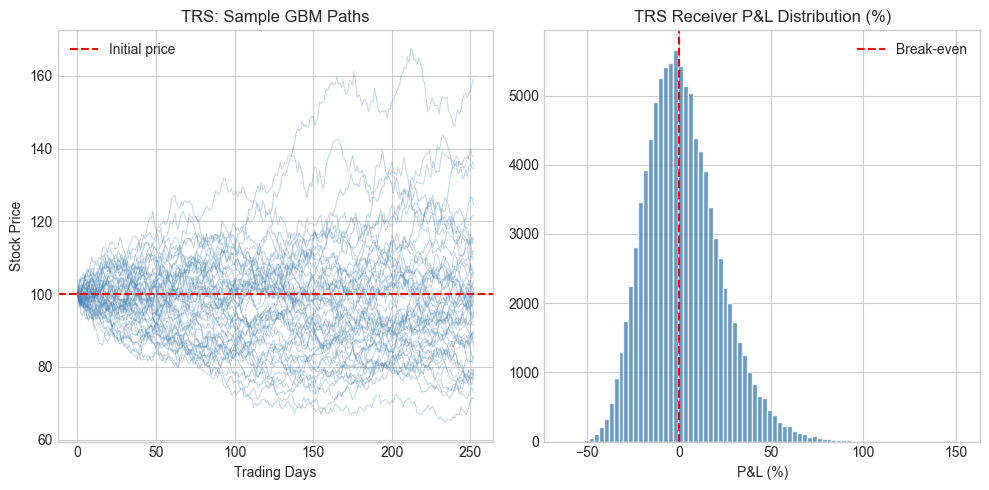

In [ ]:
# --- Total Return Swap ---
q = 0.02  # dividend yield
r_fixed = r - q
print(f'Fair fixed rate on TRS: {r_fixed*100:.2f}%')

# Simulate TRS P&L for the receiver over 1 year
paths = simulate_gbm(S0, r - q, sigma, T, steps, N) # simulate 100k paths of GBM with dividend yield
S_T = paths[:, -1] # terminal stock price at T for each path

# Total return receiver payoff (normalised per unit notional)
price_return = (S_T - S0) / S0
total_return = price_return + q * T       # add dividend yield
funding_cost = r_fixed * T                # fixed leg paid
pnl = total_return - funding_cost

print(f'Expected P&L (receiver): {np.mean(pnl)*100:.4f}%  (should be ~0 under risk-neutral)')
print(f'Std Dev of P&L:          {np.std(pnl)*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Path sample
for i in range(50):
    axes[0].plot(paths[i], alpha=0.3, lw=0.8, color='steelblue')
axes[0].axhline(S0, color='red', lw=1.5, linestyle='--', label='Initial price')
axes[0].set_title('TRS: Sample GBM Paths')
axes[0].set_xlabel('Trading Days'); axes[0].set_ylabel('Stock Price')
axes[0].legend()

# P&L distribution
axes[1].hist(pnl * 100, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--', label='Break-even')
axes[1].set_title('TRS Receiver P&L Distribution (%)')
axes[1].set_xlabel('P&L (%)')
axes[1].legend()
plt.tight_layout(); 


### 2.2 Equity Forward

**Concept**: Agreement to buy or sell an equity at a predetermined forward price $F$ at maturity $T$.

**Forward price** (no-arbitrage):

$$F_0 = S_0 \cdot e^{(r - q)T}$$

**Payoff at maturity** for the long:

$$\text{Payoff} = S_T - F_0$$

**Value before maturity** (mark-to-market):

$$V_t = S_t \cdot e^{-q(T-t)} - F_0 \cdot e^{-r(T-t)}$$

Forward price F0 = 101.0050
MC mean payoff (discounted): -0.0823  (should be ~0)
Done.


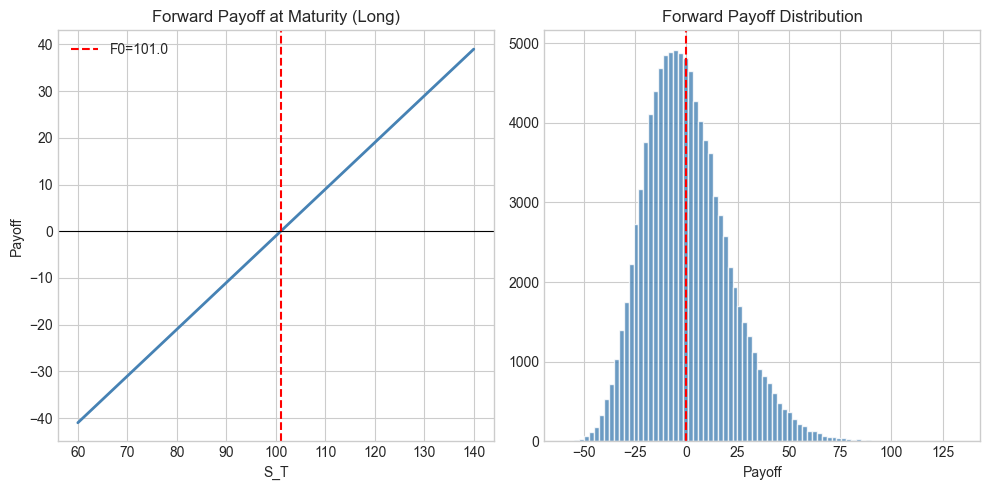

In [ ]:
# --- Equity Forward ---
F0 = S0 * np.exp((r - q) * T)
print(f'Forward price F0 = {F0:.4f}')

paths = simulate_gbm(S0, r - q, sigma, T, steps, N)
S_T = paths[:, -1]
payoff = S_T - F0

print(f'MC mean payoff (discounted): {np.mean(payoff) * np.exp(-r*T):.4f}  (should be ~0)')

# Payoff diagram
S_range = np.linspace(60, 140, 300)
payoff_diag = S_range - F0

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].plot(S_range, payoff_diag, color='steelblue', lw=2)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axvline(F0, color='red', lw=1.5, linestyle='--', label=f'F0={F0:.1f}')
axes[0].set_title('Forward Payoff at Maturity (Long)')
axes[0].set_xlabel('S_T'); axes[0].set_ylabel('Payoff')
axes[0].legend()

axes[1].hist(payoff, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_title('Forward Payoff Distribution')
axes[1].set_xlabel('Payoff')
plt.tight_layout(); 
print('Done.')

---
## 3. Vanilla Options

### 3.1 European Call and Put

**Payoffs at maturity**:

$$\text{Call payoff} = \max(S_T - K, 0)$$
$$\text{Put payoff}  = \max(K - S_T, 0)$$

**BSM Closed-Form Prices**:

$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$

where:
$$d_1 = \frac{\ln(S_0/K) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

**Put-Call Parity**:

$$C - P = S_0 e^{-qT} - K e^{-rT}$$

BSM Call price: 9.4134
BSM Put  price: 6.4580
MC   Call price: 9.2720
MC   Put  price: 6.5257

Call Greeks:
  delta: 0.5987
  gamma: 0.0193
  vega: 38.6668
  theta: -0.0147
  rho: 0.5046


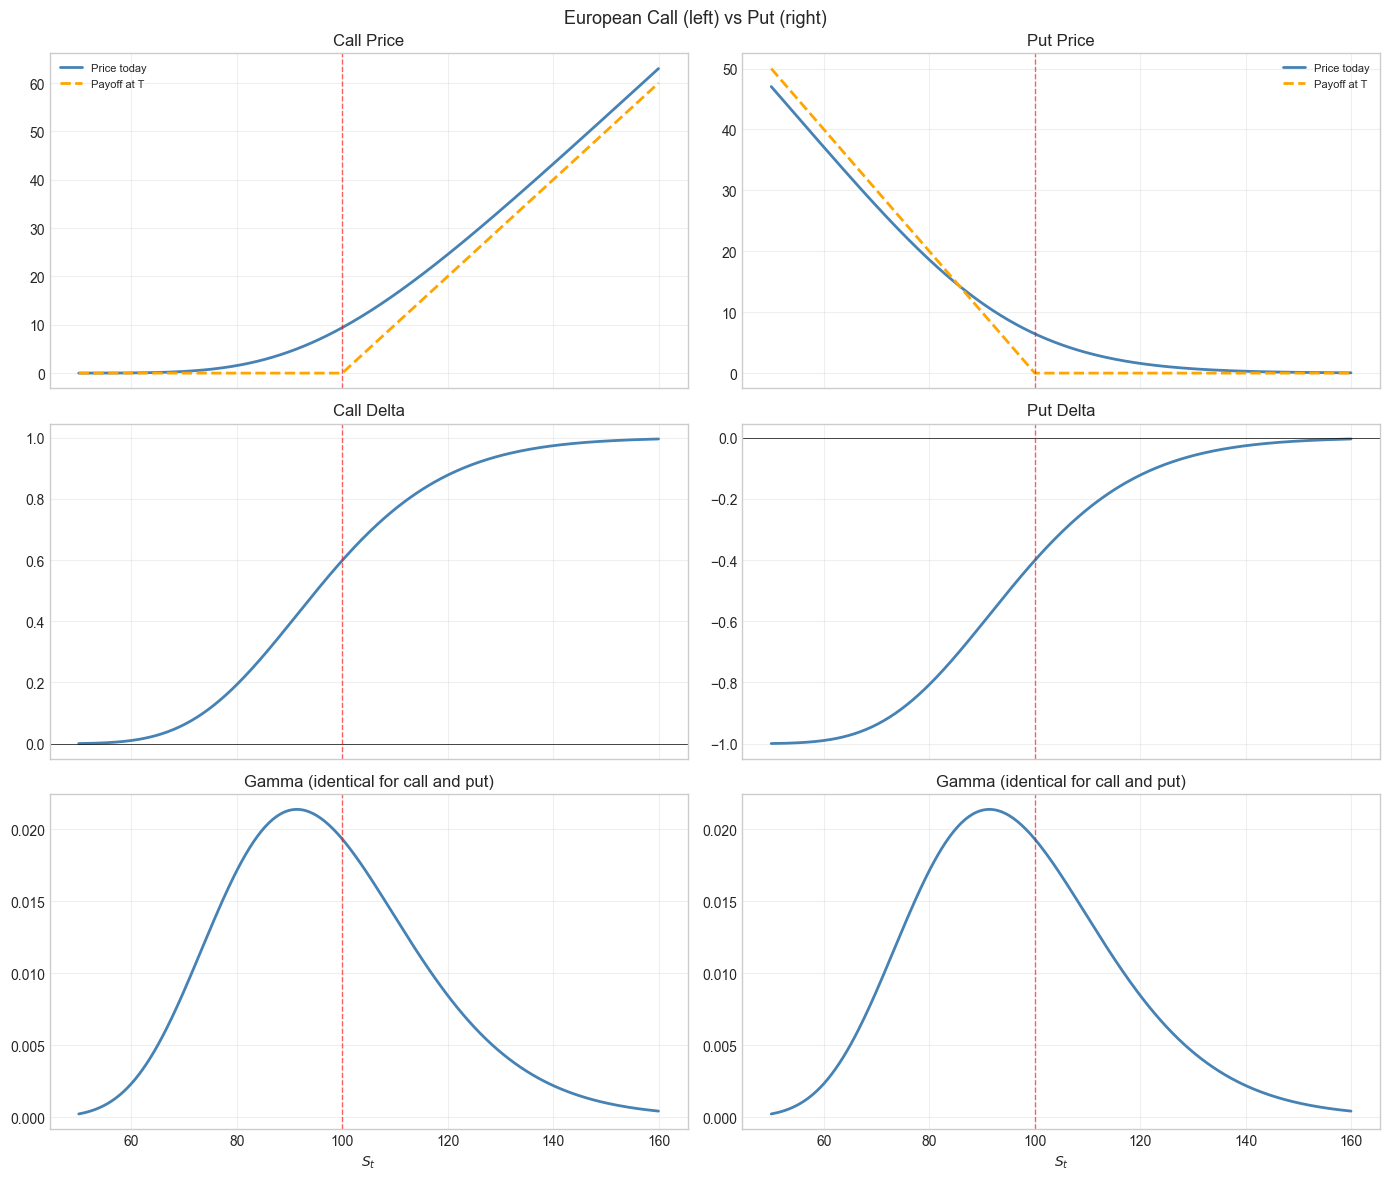

In [ ]:
# --- Vanilla Options ---
call_bsm = bsm_price(S0, K, T, r, sigma, 'call')
put_bsm  = bsm_price(S0, K, T, r, sigma, 'put')
print(f'BSM Call price: {call_bsm:.4f}')
print(f'BSM Put  price: {put_bsm:.4f}')

# Monte Carlo pricing
paths = simulate_gbm(S0, r, sigma, T, steps, N)
S_T = paths[:, -1]

# discount average payoffs back to today
call_mc = np.exp(-r*T) * np.mean(np.maximum(S_T - K, 0))
put_mc  = np.exp(-r*T) * np.mean(np.maximum(K - S_T, 0))
print(f'MC   Call price: {call_mc:.4f}')
print(f'MC   Put  price: {put_mc:.4f}')

# Greeks
greeks = bsm_greeks(S0, K, T, r, sigma, 'call')
print('\nCall Greeks:')
for k, v in greeks.items():
    print(f'  {k}: {v:.4f}')

# Payoff and price diagrams
S_range = np.linspace(50, 160, 300)
call_payoff = np.maximum(S_range - K, 0)
put_payoff  = np.maximum(K - S_range, 0)
call_prices = [bsm_price(s, K, T, r, sigma, 'call') for s in S_range]
put_prices  = [bsm_price(s, K, T, r, sigma, 'put')  for s in S_range]

# Greeks across spot prices
greeks_call = {g: [bsm_greeks(s, K, T, r, sigma, 'call')[g] for s in S_range] 
               for g in ['delta', 'gamma']}
greeks_put  = {g: [bsm_greeks(s, K, T, r, sigma, 'put')[g]  for s in S_range] 
               for g in ['delta', 'gamma']}

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
fig.suptitle('European Call (left) vs Put (right)', fontsize=13)

# Row 0: Price
axes[0,0].plot(S_range, call_prices, 'steelblue', lw=2, label='Price today')
axes[0,0].plot(S_range, call_payoff, 'orange',    lw=2, ls='--', label='Payoff at T')
axes[0,0].set_title('Call Price')
axes[0,0].legend(fontsize=8)

axes[0,1].plot(S_range, put_prices, 'steelblue', lw=2, label='Price today')
axes[0,1].plot(S_range, put_payoff, 'orange',    lw=2, ls='--', label='Payoff at T')
axes[0,1].set_title('Put Price')
axes[0,1].legend(fontsize=8)

# Row 1: Delta
axes[1,0].plot(S_range, greeks_call['delta'], 'steelblue', lw=2)
axes[1,0].set_title('Call Delta')
axes[1,0].axhline(0, color='black', lw=0.5)

axes[1,1].plot(S_range, greeks_put['delta'], 'steelblue', lw=2)
axes[1,1].set_title('Put Delta')
axes[1,1].axhline(0, color='black', lw=0.5)

# Row 2: Gamma (same for call and put)
for col in [0, 1]:
    axes[2,col].plot(S_range, greeks_call['gamma'], 'steelblue', lw=2)
    axes[2,col].set_title('Gamma (identical for call and put)')
    axes[2,col].set_xlabel('$S_t$')

# ATM line across all panels
for ax in axes.flat:
    ax.axvline(K, color='red', lw=1, ls='--', alpha=0.6, label='ATM' if ax == axes[0,0] else '')
    ax.grid(True, alpha=0.3)

plt.tight_layout()


#### Plotting Derivative Surfaces

Plotting implied volatility, vega and theta against:
- moneyness $K/S_0$
- time to maturity $T-t$

for calls (left column) and puts (right column), using market prices from SPY option chain.

SPY spot: 747.27
Using expiries: ('2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-29')
Total clean option records: 703


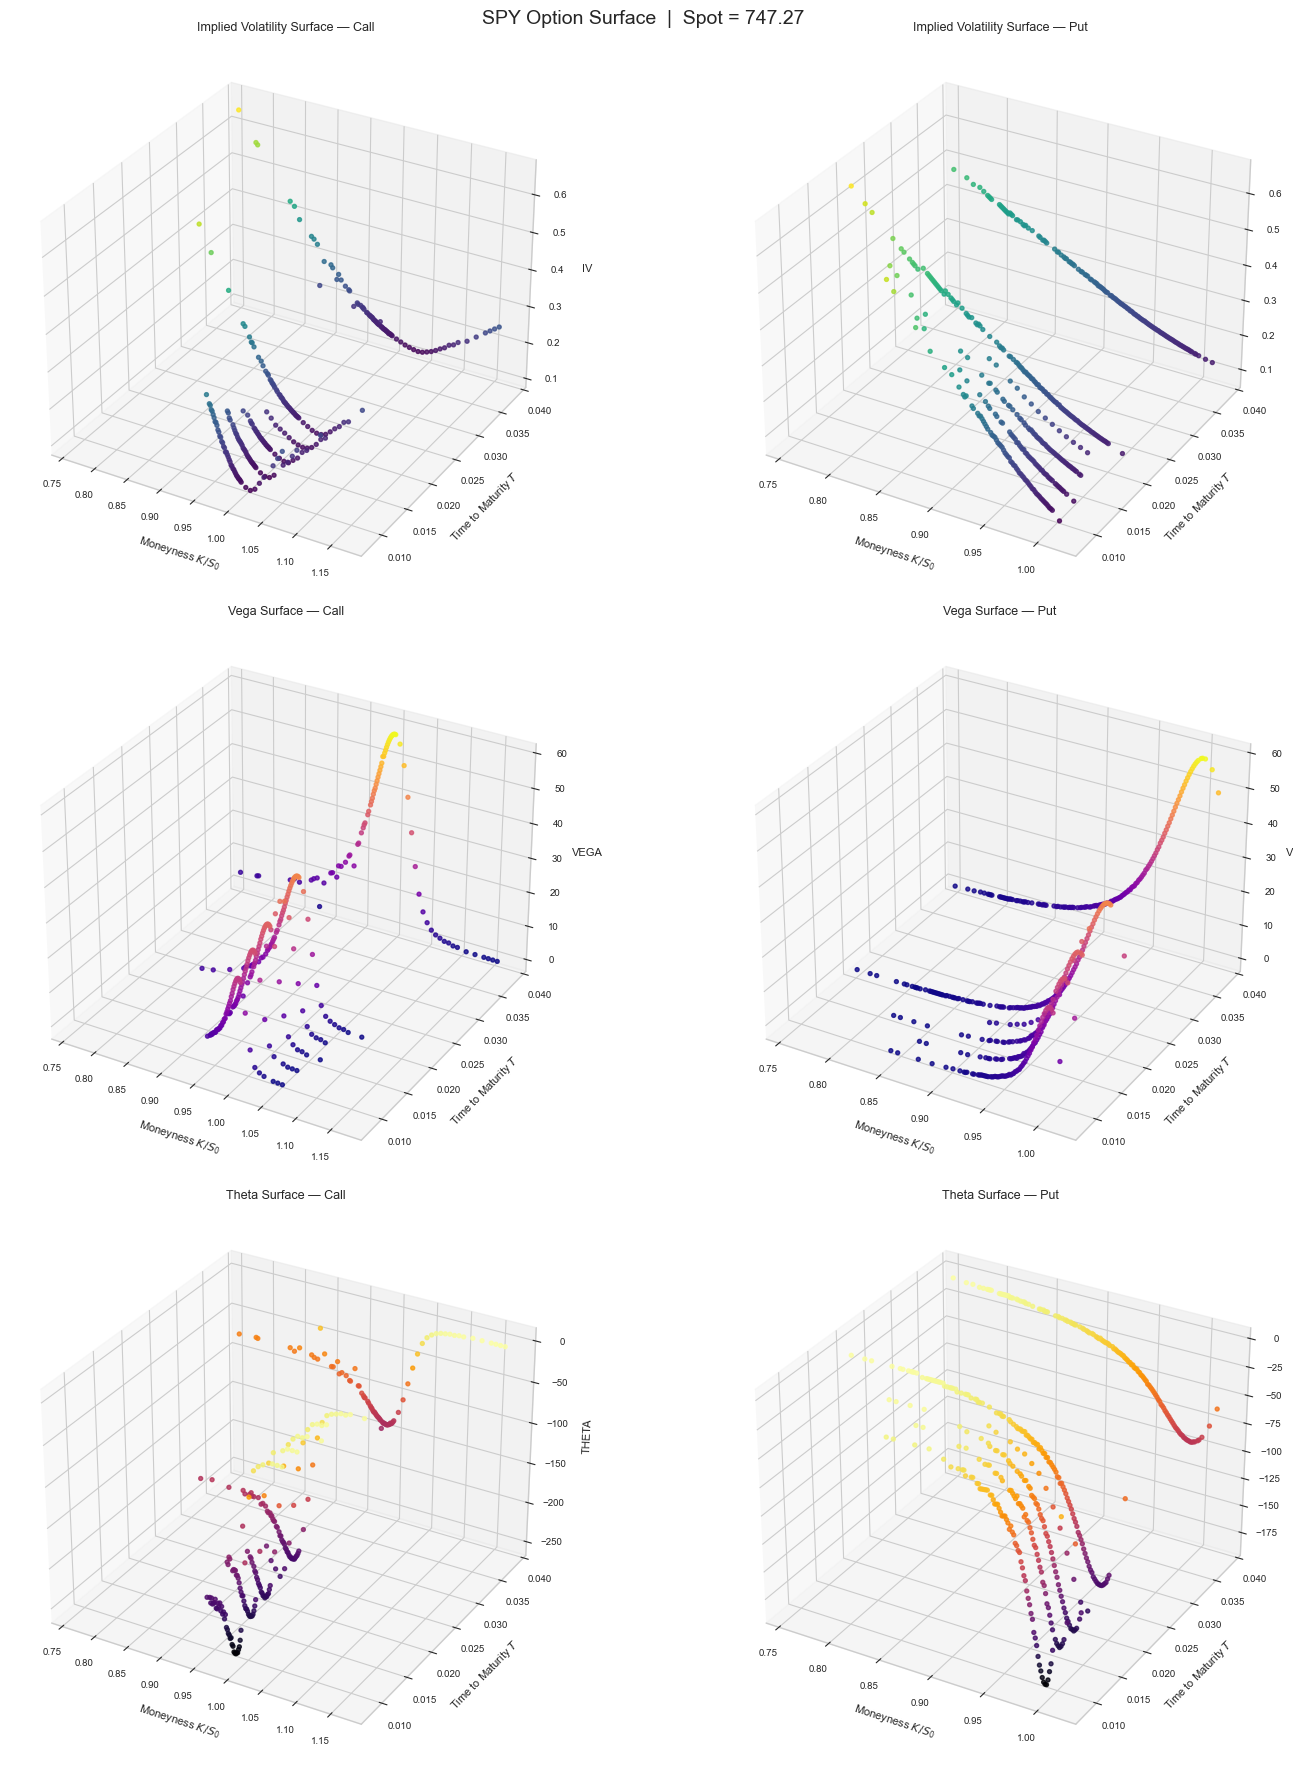

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# ── BSM pricer and IV inverter ───────────────────────────────────────────────

def bsm_price(S, K, T, r, sigma, flag):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0) if flag == 'call' else max(K - S, 0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if flag == 'call':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def implied_vol(price, S, K, T, r, flag, tol=1e-6):
    """Brent method to invert BSM for implied vol."""
    intrinsic = max(S - K, 0) if flag == 'call' else max(K - S, 0)
    if price <= intrinsic + tol or T <= 0:
        return np.nan
    try:
        iv = brentq(
            lambda s: bsm_price(S, K, T, r, s, flag) - price,
            1e-4, 5.0, xtol=tol, maxiter=200
        )
        return iv if 0.01 < iv < 4.0 else np.nan
    except:
        return np.nan

# ── BSM Greeks ───────────────────────────────────────────────────────────────

def bsm_greek(S, K, T, r, sigma, flag, greek):
    if T <= 0 or sigma <= 0:
        return np.nan
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    npdf_d1 = norm.pdf(d1)
    if greek == 'vega':
        return S * npdf_d1 * np.sqrt(T)          # same for call and put
    elif greek == 'theta':
        base = -(S * npdf_d1 * sigma) / (2*np.sqrt(T))
        if flag == 'call':
            return base - r*K*np.exp(-r*T)*norm.cdf(d2)
        else:
            return base + r*K*np.exp(-r*T)*norm.cdf(-d2)
    elif greek == 'rho':
        if flag == 'call':
            return K*T*np.exp(-r*T)*norm.cdf(d2)
        else:
            return -K*T*np.exp(-r*T)*norm.cdf(-d2)

# ── Download SPY option chain ─────────────────────────────────────────────────

ticker = 'SPY'
tk     = yf.Ticker(ticker)
S0     = tk.history(period='1d')['Close'].iloc[-1]
r      = 0.05
print(f'SPY spot: {S0:.2f}')

expiries = tk.options[:8]   # first 8 expiries
print(f'Using expiries: {expiries}')

records = []
for exp in expiries:
    chain = tk.option_chain(exp)
    T = (pd.Timestamp(exp) - pd.Timestamp.today()).days / 365.0
    if T <= 0:
        continue
    for flag, df in [('call', chain.calls), ('put', chain.puts)]:
        df = df.copy()
        # filter: volume, open interest, spread
        df = df[(df['volume'] > 10) & (df['openInterest'] > 50)]
        df = df[(df['ask'] > df['bid']) & (df['bid'] > 0)]
        df['mid']       = (df['bid'] + df['ask']) / 2
        df['moneyness'] = df['strike'] / S0
        # keep near-the-money: moneyness in [0.75, 1.25]
        df = df[(df['moneyness'] >= 0.75) & (df['moneyness'] <= 1.25)]
        for _, row in df.iterrows():
            iv = implied_vol(row['mid'], S0, row['strike'], T, r, flag)
            if np.isnan(iv):
                continue
            vega  = bsm_greek(S0, row['strike'], T, r, iv, flag, 'vega')
            theta = bsm_greek(S0, row['strike'], T, r, iv, flag, 'theta')
            rho   = bsm_greek(S0, row['strike'], T, r, iv, flag, 'rho')
            records.append({
                'flag': flag, 'strike': row['strike'], 'T': T,
                'moneyness': row['moneyness'], 'iv': iv,
                'vega': vega, 'theta': theta, 'rho': rho
            })

import pandas as pd
df_all = pd.DataFrame(records)
print(f'Total clean option records: {len(df_all)}')

# ── 3D plotting function ──────────────────────────────────────────────────────

def plot_surface_3d(ax, df, flag, y_col, title, cmap='plasma'):
    sub = df[df['flag'] == flag].dropna(subset=[y_col])
    ax.scatter(
        sub['moneyness'], sub['T'], sub[y_col],
        c=sub[y_col], cmap=cmap, s=8, alpha=0.8
    )
    ax.set_xlabel('Moneyness $K/S_0$', fontsize=8)
    ax.set_ylabel('Time to Maturity $T$', fontsize=8)
    ax.set_zlabel(y_col.upper(), fontsize=8)
    ax.set_title(f'{title} — {flag.capitalize()}', fontsize=9)
    ax.tick_params(labelsize=7)

# ── Figure: 3 rows x 2 columns ───────────────────────────────────────────────

fig = plt.figure(figsize=(16, 18))
fig.suptitle(f'SPY Option Surface  |  Spot = {S0:.2f}', fontsize=14, y=0.98)

surface_specs = [
    ('iv',    'Implied Volatility Surface', 'viridis'),
    ('vega',  'Vega Surface',               'plasma'),
    ('theta', 'Theta Surface',              'inferno'),
]

for row, (col, title, cmap) in enumerate(surface_specs):
    for c, flag in enumerate(['call', 'put']):
        ax = fig.add_subplot(3, 2, row*2 + c + 1, projection='3d')
        plot_surface_3d(ax, df_all, flag, col, title, cmap)

plt.tight_layout()
plt.show()

---
## 4. Contract for Difference (CFD)

A CFD allows the client to gain exposure to the price movement of an asset without 
owning it. The client and the broker agree to exchange the difference in the asset's 
price between the opening and closing of the contract. CFDs are OTC contracts, 
economically similar to futures but with no expiry date and no standardization.


** P&L Long CFD**:

$$\text{P\&L} = N \cdot (S_{\text{close}} - S_{\text{open}}) + \text{Dividend adjustment} - \text{Financing cost}$$

** P&L Short CFD**:

$$\text{P\&L} = N \cdot (S_{\text{open}} - S_{\text{close}}) - \text{Dividend adjustment} + \text{Interest received} - \text{Borrow cost}$$



For a long CFD held overnight:

$$\text{Financing cost} = N \cdot S_{\text{open}} \cdot (\text{SOFR} + \text{spread}) \cdot \frac{\text{days}}{360}$$

For a short CFD the client receives interest on the short proceeds minus a borrow cost:

$$\text{Net financing received} = N \cdot S_{\text{open}} \cdot (\text{SOFR} - \text{borrow rate}) \cdot \frac{\text{days}}{360}$$

**Dividend adjustment**

The CFD replicates economic ownership without legal ownership:

- **Long CFD**: client receives a cash dividend adjustment on the ex-dividend date
- **Short CFD**: client pays the dividend adjustment

$$\text{Dividend adjustment} = N \cdot D$$

where $D$ is the gross dividend per share. Note that the adjustment is on the **gross** 
dividend, not the net, since the client does not benefit from dividend tax credits.

**Key features**

- **Leverage**: client posts margin, typically 10-20% of notional for equities, 
  as low as 2-3% for major FX pairs. Gains and losses are on the full notional.
- **No stamp duty** in many jurisdictions since there is no transfer of legal ownership.
- **Short selling** is straightforward with no need to locate and borrow stock directly.
- **Mark to market daily**: margin calls if the position moves against the client. 
  Losses can exceed the initial margin posted.
- **Corporate actions**: splits, rights issues, and spin-offs are adjusted 
  contractually by the broker to maintain economic equivalence.

#### CFD vs Futures

<small> 

| | CFD | Future |
|---|---|---|
| Expiry | None, rolls daily | Fixed expiry, must roll |
| Standardization | No, flexible notional | Yes, fixed contract size |
| Counterparty risk | Broker (OTC) | Exchange cleared, minimal |
| Dividends | Adjusted explicitly | Priced into forward |
| Financing | SOFR + spread daily | Implicit in futures price |
| Availability | Retail and institutional | Mainly institutional |

</small> 


CFDs are OTC contracts. If the broker defaults the client holds an unsecured claim 
on the broker for the mark-to-market value of open positions. This is a structural 
risk absent from exchange-traded products. In some jurisdictions client funds must 
be held in segregated accounts, but this protection varies significantly.


- **United States**: CFDs are banned for retail clients and unavailable on US exchanges.
- **European Union and UK**: available for retail clients subject to ESMA leverage 
  limits introduced in 2018: 2:1 for crypto, 5:1 for single equities, 20:1 for 
  major indices, 30:1 for major FX pairs.
- **Asia**: available in most jurisdictions with varying leverage limits.

Initial margin posted  : 2,000
Daily financing cost   : 1.67  (SOFR 5.0% + spread 1.0%)
Daily dividend received: 0.60
Total financing cost   : 50.00
Total dividends        : 17.86
Final stock price      : 753.02
Final cumulative P&L   : 44.83
Return on margin       : 2.24%
No margin call triggered


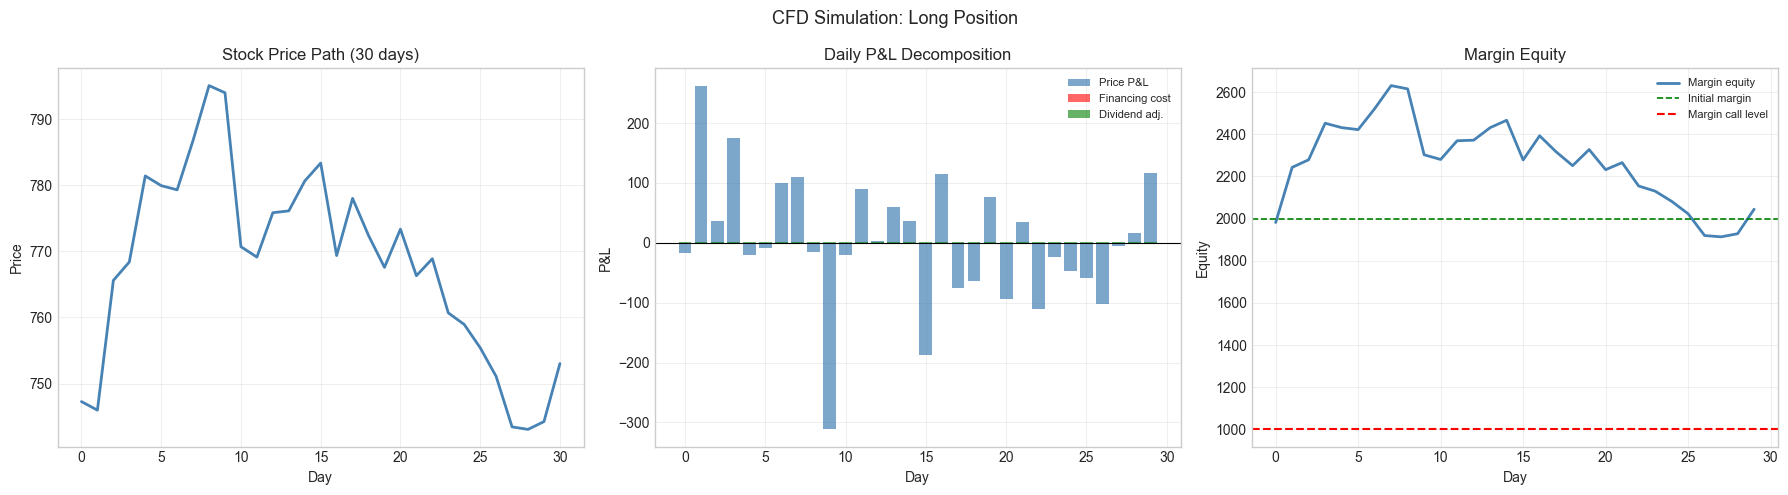

In [ ]:
# --- CFD Simulation - oly illustrating dynamic margining ---
leverage      = 5        # 5x leverage (20% margin)
notional      = 10000.0  # notional exposure
margin        = notional / leverage
sofr          = 0.05     # SOFR
spread        = 0.01     # broker spread over SOFR
r_financing   = sofr + spread
div_yield     = 0.015    # continuous dividend yield (e.g. SPY ~1.5%)
n_days        = 30
margin_call_level = 0.5  # margin call if equity < 50% of initial margin

np.random.seed(99)

# price path reflects capital appreciation only (ex-dividend)
daily_returns = np.random.normal(
    (r - div_yield - 0.5*sigma**2)/252, 
    sigma/np.sqrt(252), 
    n_days
)
prices = S0 * np.cumprod(np.exp(daily_returns))
prices = np.insert(prices, 0, S0)

units     = notional / S0
daily_pnl = units * np.diff(prices)          # capital appreciation only
daily_fin = notional * r_financing / 360     # financing drag
daily_div = notional * div_yield / 252       # dividend cash received separately
net_daily = daily_pnl - daily_fin + daily_div

cumulative_pnl = np.cumsum(net_daily)
equity         = margin + cumulative_pnl
margin_pct     = equity / margin * 100

# Detect margin call
margin_call_day = next(
    (i for i, e in enumerate(equity) if e < margin * margin_call_level), None
)

print(f'Initial margin posted  : {margin:,.0f}')
print(f'Daily financing cost   : {daily_fin:.2f}  (SOFR {sofr*100:.1f}% + spread {spread*100:.1f}%)')
print(f'Daily dividend received: {daily_div:.2f}')
print(f'Total financing cost   : {daily_fin*n_days:.2f}')
print(f'Total dividends        : {daily_div*n_days:.2f}')
print(f'Final stock price      : {prices[-1]:.2f}')
print(f'Final cumulative P&L   : {cumulative_pnl[-1]:,.2f}')
print(f'Return on margin       : {cumulative_pnl[-1]/margin*100:.2f}%')
if margin_call_day:
    print(f'MARGIN CALL triggered on day {margin_call_day}')
else:
    print('No margin call triggered')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CFD Simulation: Long Position', fontsize=13)

# Panel 1: price path
axes[0].plot(prices, color='steelblue', lw=2)
axes[0].set_title('Stock Price Path (30 days)')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

# Panel 2: P&L decomposition
days = np.arange(n_days)
axes[1].bar(days, daily_pnl,  color='steelblue', alpha=0.7, label='Price P&L')
axes[1].bar(days, -daily_fin * np.ones(n_days), color='red',      alpha=0.6, label='Financing cost')
axes[1].bar(days,  daily_div * np.ones(n_days), color='green',    alpha=0.6, label='Dividend adj.')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Daily P&L Decomposition')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('P&L')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: margin equity
axes[2].plot(equity, color='steelblue', lw=2, label='Margin equity')
axes[2].axhline(margin,                    color='green', lw=1.2, ls='--', label='Initial margin')
axes[2].axhline(margin * margin_call_level, color='red',   lw=1.5, ls='--', label='Margin call level')
if margin_call_day:
    axes[2].axvline(margin_call_day, color='orange', lw=1.5, ls=':', label=f'Margin call day {margin_call_day}')
axes[2].set_title('Margin Equity')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Equity')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Digital Options

A digital option pays a fixed amount if the stock is above (call) or below (put) 
the strike at expiry, and zero otherwise. There are two types:

**Cash-or-Nothing**: pays a fixed cash amount $Q$ if $S_T > K$ (call) or $S_T < K$ (put):

$$\text{Payoff}_{\text{call}} = Q \cdot \mathbf{1}\{S_T > K\}$$
$$\text{Payoff}_{\text{put}} = Q \cdot \mathbf{1}\{S_T < K\}$$

**Asset-or-Nothing**: pays the asset itself $S_T$ if $S_T > K$ (call) or $S_T < K$ (put):

$$\text{Payoff}_{\text{call}} = S_T \cdot \mathbf{1}\{S_T > K\}$$
$$\text{Payoff}_{\text{put}} = S_T \cdot \mathbf{1}\{S_T < K\}$$

**Note.** The asset-or-nothing differs from a vanilla call in that there is no 
payment of the strike $K$ at expiry. If $S_T > K$, you simply receive $S_T$ in 
full with no exchange. It is not free in the sense that you pay a premium at 
inception, but conditional on finishing in the money, you receive the entire 
asset value rather than just the intrinsic value $S_T - K$. This is why the 
vanilla call is just the asset-or-nothing minus the discounted strike payment:

$$C_{\text{vanilla}} = \underbrace{C_{\text{AoN}}}_{\text{receive } S_T} - \underbrace{K e^{-rT} \cdot C_{\text{CoN}}}_{\text{pay } K}$$
### BSM Closed-Form Prices

**Cash-or-Nothing**:

$$C_{\text{CoN}} = Q \cdot e^{-rT} \mathcal{N}(d_2), \qquad P_{\text{CoN}} = Q \cdot e^{-rT} \mathcal{N}(-d_2)$$

**Asset-or-Nothing**:

$$C_{\text{AoN}} = S_0 \cdot \mathcal{N}(d_1), \qquad P_{\text{AoN}} = S_0 \cdot \mathcal{N}(-d_1)$$

Note that a vanilla call decomposes as:

$$C_{\text{vanilla}} = C_{\text{AoN}} - K e^{-rT} \cdot C_{\text{CoN}}$$

that is, long an asset-or-nothing call and short $K$ cash-or-nothing calls.

### Risk near expiry

The cash-or-nothing delta spikes sharply near $K$ as $T \to 0$:

$$\Delta_{\text{CoN}} = \frac{\partial C_{\text{CoN}}}{\partial S_0} = Q \cdot e^{-rT} \frac{\mathcal{N}'(d_2)}{S_0 \sigma \sqrt{T}}$$

As $T \to 0$ and $S_0 \approx K$, $\Delta_{\text{CoN}} \to \infty$. This makes 
digitals very hard to hedge near expiry and explains why in practice they are 
replicated with a tight call spread:

$$C_{\text{CoN}} \approx \frac{C(K - \varepsilon) - C(K + \varepsilon)}{2\varepsilon}$$

## 6. Chooser Option

At a future date $t_c < T$ the holder chooses whether the option becomes a 
**call or a put**, both with the same strike $K$ and maturity $T$.

$$\text{Payoff at } t_c = \max\left(C_{\text{BSM}}(S_{t_c}, K, T-t_c, r, \sigma),\ 
P_{\text{BSM}}(S_{t_c}, K, T-t_c, r, \sigma)\right)$$

Using put-call parity at $t_c$:

$$P_{\text{BSM}} = C_{\text{BSM}} - S_{t_c} + Ke^{-r(T-t_c)}$$

the chooser simplifies to:

$$\text{Payoff at } t_c = C_{\text{BSM}}(S_{t_c}, K, T-t_c, r, \sigma) + 
\max\left(Ke^{-r(T-t_c)} - S_{t_c},\ 0\right)$$

This is a **vanilla call** with maturity $T$ plus a **put** with maturity $t_c$ 
and strike $Ke^{-r(T-t_c)}$. So the closed-form price at $t=0$ is:

$$V_{\text{chooser}} = C_{\text{BSM}}(S_0, K, T, r, \sigma) + 
P_{\text{BSM}}\left(S_0, Ke^{-r(T-t_c)}, t_c, r, \sigma\right)$$

**Finance application**: the chooser is used when the investor expects a large 
move but does not yet know the direction, for example around a major earnings 
announcement or central bank decision. It is more flexible than a straddle 
because the direction decision is deferred to $t_c$.

**Comparison to straddle**: a straddle buys both call and put immediately. 
A chooser only activates one of them at $t_c$, making it cheaper than a 
straddle but more expensive than a single vanilla option.

---

## 7. Compound Option

A compound option is an **option on an option**. At date $t_c < T$ the holder 
pays a second premium $K_c$ to activate the underlying option with strike $K$ 
and maturity $T$. There are four types:
<small> 

| Type | Payoff at $t_c$ |
|---|---|
| Call on call | $\max(C_{\text{BSM}}(S_{t_c}, K, T-t_c, r, \sigma) - K_c,\ 0)$ |
| Put on call | $\max(K_c - C_{\text{BSM}}(S_{t_c}, K, T-t_c, r, \sigma),\ 0)$ |
| Call on put | $\max(P_{\text{BSM}}(S_{t_c}, K, T-t_c, r, \sigma) - K_c,\ 0)$ |
| Put on put | $\max(K_c - P_{\text{BSM}}(S_{t_c}, K, T-t_c, r, \sigma),\ 0)$ |

</small> 


**Closed-form price** for a call on a call (Geske 1979):

$$V = S_0 \mathcal{N}_2(a_1, b_1; \rho) - Ke^{-rT}\mathcal{N}_2(a_2, b_2; \rho) 
- K_c e^{-rt_c}\mathcal{N}(a_2)$$

where $\mathcal{N}_2(\cdot, \cdot; \rho)$ is the bivariate normal CDF with 
correlation $\rho = \sqrt{t_c/T}$, and:

$$a_1 = \frac{\ln(S_0/S^*) + (r + \frac{\sigma^2}{2})t_c}{\sigma\sqrt{t_c}}, 
\quad a_2 = a_1 - \sigma\sqrt{t_c}$$

$$b_1 = \frac{\ln(S_0/K) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, 
\quad b_2 = b_1 - \sigma\sqrt{T}$$

where $S^*$ is the critical stock price at $t_c$ such that 
$C_{\text{BSM}}(S^*, K, T-t_c, r, \sigma) = K_c$.

**Finance application**: compound options model **staged investments** where 
the investor pays a small premium now for the right to pay a larger premium 
later if conditions are favorable. Common in:
- **R&D financing**: pay now for the right to fund the next stage
- **Real options**: option to expand a project contingent on early results
- **Mortgage caps**: a cap on a cap, limiting interest rate exposure in stages

Vanilla call            : 647.4616
Vanilla put             : 0.0000
Straddle (call + put)   : 647.4616
Chooser (tc=0.25)        : 647.4616
Chooser cheaper than straddle by: 0.0000

Call on call (Kc=5.0)  : 643.5429
Vanilla call            : 647.4616
Compound cheaper by     : 3.9187


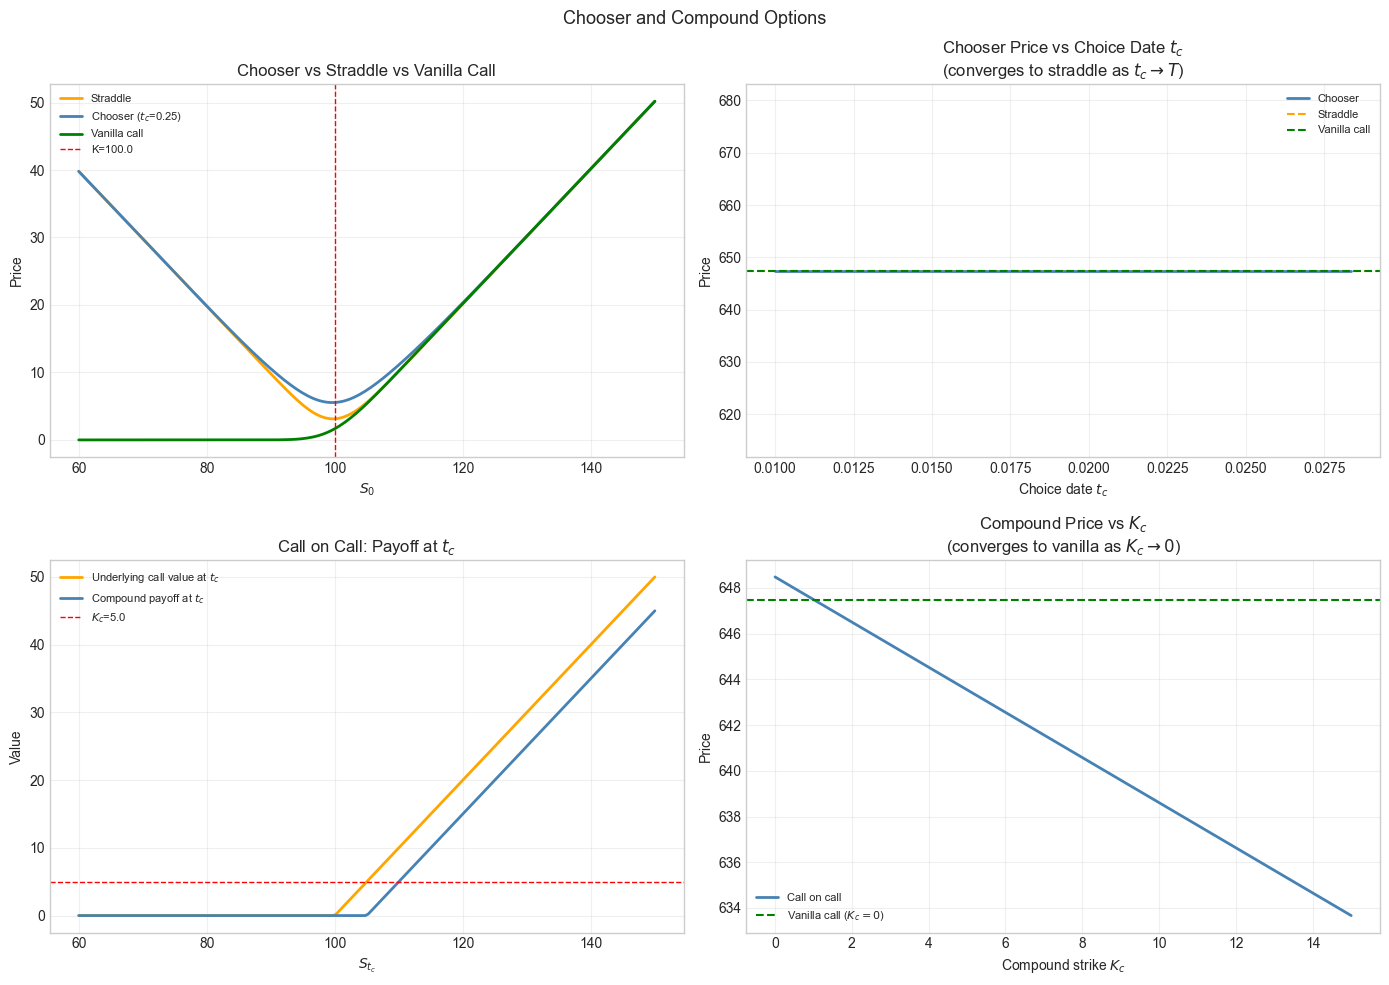

In [ ]:
# --- Chooser and Compound Options ---

from scipy.stats import multivariate_normal

def chooser_price(S, K, T, tc, r, sigma):
    """
    Chooser option = vanilla call(T) + put(tc, K*exp(-r*(T-tc)))
    """
    K_put = K * np.exp(-r*(T-tc))
    call  = bsm_price(S, K,     T,  r, sigma, 'call')
    put   = bsm_price(S, K_put, tc, r, sigma, 'put')
    return call + put

def compound_call_on_call_mc(S0, K, Kc, T, tc, r, sigma, N_paths=50000, seed=42):
    """
    Monte Carlo for call on call compound option.
    At tc: if C_BSM(S_tc, K, T-tc, r, sigma) > Kc, pay Kc and get the call.
    """
    np.random.seed(seed)
    Z    = np.random.standard_normal(N_paths)
    S_tc = S0 * np.exp((r - 0.5*sigma**2)*tc + sigma*np.sqrt(tc)*Z)
    inner_call = np.array([bsm_price(s, K, T-tc, r, sigma, 'call') for s in S_tc])
    payoff = np.maximum(inner_call - Kc, 0)
    return np.exp(-r*tc) * payoff.mean()

# Parameters
tc = 0.25   # chooser/compound decision date
Kc = 5.0    # compound strike (cost to activate underlying option)

# Chooser pricing
chooser = chooser_price(S0, K, T, tc, r, sigma)
vanilla_call = bsm_price(S0, K, T, r, sigma, 'call')
vanilla_put  = bsm_price(S0, K, T, r, sigma, 'put')
straddle     = vanilla_call + vanilla_put

print(f'Vanilla call            : {vanilla_call:.4f}')
print(f'Vanilla put             : {vanilla_put:.4f}')
print(f'Straddle (call + put)   : {straddle:.4f}')
print(f'Chooser (tc={tc})        : {chooser:.4f}')
print(f'Chooser cheaper than straddle by: {straddle - chooser:.4f}')

# Compound pricing
compound = compound_call_on_call_mc(S0, K, Kc, T, tc, r, sigma)
print(f'\nCall on call (Kc={Kc})  : {compound:.4f}')
print(f'Vanilla call            : {vanilla_call:.4f}')
print(f'Compound cheaper by     : {vanilla_call - compound:.4f}')

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chooser and Compound Options', fontsize=13)

S_range = np.linspace(60, 150, 200)

# Panel 1: Chooser vs straddle vs vanilla call across spot
chooser_p  = [chooser_price(s, K, T, tc, r, sigma) for s in S_range]
straddle_p = [bsm_price(s, K, T, r, sigma, 'call') + 
              bsm_price(s, K, T, r, sigma, 'put')   for s in S_range]
call_p     = [bsm_price(s, K, T, r, sigma, 'call') for s in S_range]

axes[0,0].plot(S_range, straddle_p, color='orange',    lw=2, label='Straddle')
axes[0,0].plot(S_range, chooser_p,  color='steelblue', lw=2, label=f'Chooser ($t_c$={tc})')
axes[0,0].plot(S_range, call_p,     color='green',     lw=2, label='Vanilla call')
axes[0,0].axvline(K, color='red', lw=1, ls='--', label=f'K={K}')
axes[0,0].set_title('Chooser vs Straddle vs Vanilla Call')
axes[0,0].set_xlabel('$S_0$')
axes[0,0].set_ylabel('Price')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# Panel 2: Chooser price vs tc (choice date)
tc_range   = np.linspace(0.01, T-0.01, 50)
chooser_tc = [chooser_price(S0, K, T, tc_i, r, sigma) for tc_i in tc_range]
axes[0,1].plot(tc_range, chooser_tc,              color='steelblue', lw=2, label='Chooser')
axes[0,1].axhline(straddle,    color='orange', lw=1.5, ls='--', label='Straddle')
axes[0,1].axhline(vanilla_call, color='green',  lw=1.5, ls='--', label='Vanilla call')
axes[0,1].set_title('Chooser Price vs Choice Date $t_c$\n(converges to straddle as $t_c \\to T$)')
axes[0,1].set_xlabel('Choice date $t_c$')
axes[0,1].set_ylabel('Price')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# Panel 3: Compound payoff diagram at tc
S_tc_range  = np.linspace(60, 150, 200)
inner_calls = [bsm_price(s, K, T-tc, r, sigma, 'call') for s in S_tc_range]
compound_payoff = [max(c - Kc, 0) for c in inner_calls]
axes[1,0].plot(S_tc_range, inner_calls,     color='orange',    lw=2, label='Underlying call value at $t_c$')
axes[1,0].plot(S_tc_range, compound_payoff, color='steelblue', lw=2, label='Compound payoff at $t_c$')
axes[1,0].axhline(Kc, color='red', lw=1, ls='--', label=f'$K_c$={Kc}')
axes[1,0].set_title('Call on Call: Payoff at $t_c$')
axes[1,0].set_xlabel('$S_{t_c}$')
axes[1,0].set_ylabel('Value')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

# Panel 4: Compound price vs Kc
Kc_range    = np.linspace(0, 15, 20)
compound_kc = [compound_call_on_call_mc(S0, K, kc, T, tc, r, sigma) for kc in Kc_range]
axes[1,1].plot(Kc_range, compound_kc,               color='steelblue', lw=2, label='Call on call')
axes[1,1].axhline(vanilla_call, color='green', lw=1.5, ls='--', label='Vanilla call ($K_c=0$)')
axes[1,1].set_title('Compound Price vs $K_c$\n(converges to vanilla as $K_c \\to 0$)')
axes[1,1].set_xlabel('Compound strike $K_c$')
axes[1,1].set_ylabel('Price')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Path Dependent Pricing


## 8. Barrier Options

Barrier options are **path-dependent**: the payoff depends not only on the final stock price but on whether the stock price hits a barrier $H$ during the life of the option.

### 8.1 Down-and-Out Call (Knock-Out)

**Concept**: A standard call that is cancelled (knocked out) if the stock falls to or below the barrier $H < S_0$ at any point before maturity. Cheaper than a vanilla call because there is a risk of losing the option.

**Payoff**:

$$\text{Payoff} = \max(S_T - K, 0) \cdot \mathbf{1}\{\min_{t \leq T} S_t > H\}$$

**Closed-form BSM price** (for $H \leq K$):

Interesting closed-form solution: difference of 2 BSM calls, one evaluated at $S_0$ and the second, scaled by a factor and evaluated at $\frac{H^2}{S_0}$.
$$C_{\text{knock-out}} =C_{\text{DO}} = C_{\text{BSM}}(S_0, K, T, r, \sigma) - \left(\frac{H}{S_0}\right)^{2\lambda} C_{\text{BSM}}\left(\frac{H^2}{S_0}, K, T, r, \sigma\right)$$

where $\lambda = \frac{r}{\sigma^2} + \frac{1}{2}$, and the formula holds for $H \leq K$.


### 8.2 Down-and-In Call (Knock-In)

**Concept**: A call that only becomes active if the stock hits the barrier $H$ at some point. Cheaper than vanilla. Client bets the stock first drops then recovers.

**Payoff**:

$$\text{Payoff} = \max(S_T - K, 0) \cdot \mathbf{1}\{\min_{t \leq T} S_t \leq H\}$$

**Parity relationship**:

$$C_{\text{knock-in}} + C_{\text{knock-out}} = C_{\text{vanilla}}$$

### 8.3 Up-and-Out Call

**Concept**: A call that is cancelled if the stock rises above barrier $H > S_0$. Used when client believes stock goes up but not too far. Caps the upside but reduces the premium.

**Payoff**:

$$\text{Payoff} = \max(S_T - K, 0) \cdot \mathbf{1}\{\max_{t \leq T} S_t < H\}$$

$$C_{\text{UO}} = C_{\text{BSM}}(S_0, K, T, r, \sigma) - \left(\frac{H}{S_0}\right)^{2\lambda} C_{\text{BSM}}\left(\frac{H^2}{S_0}, K, T, r, \sigma\right) - (H - K)\left(\frac{H}{S_0}\right)^{2\lambda} e^{-rT} \mathcal{N}(d)$$

where $\lambda = \frac{r}{\sigma^2} + \frac{1}{2}$, $d = \frac{\ln(H^2/S_0 K)}{\sigma\sqrt{T}} + \lambda\sigma\sqrt{T}$, and the formula holds for $K < H$.

Vanilla Call      : 9.3638
Down-and-Out Call : 9.2900  (barrier H=80.0)
Down-and-In  Call : 0.0737  (barrier H=80.0)
Parity check DO+DI: 9.3638  (should equal vanilla)
Up-and-Out   Call : 1.3074  (barrier H=120.0)
Up-and-In    Call : 8.0563  (barrier H=120.0)
Parity check UO+UI: 9.3638  (should equal vanilla)
Done.


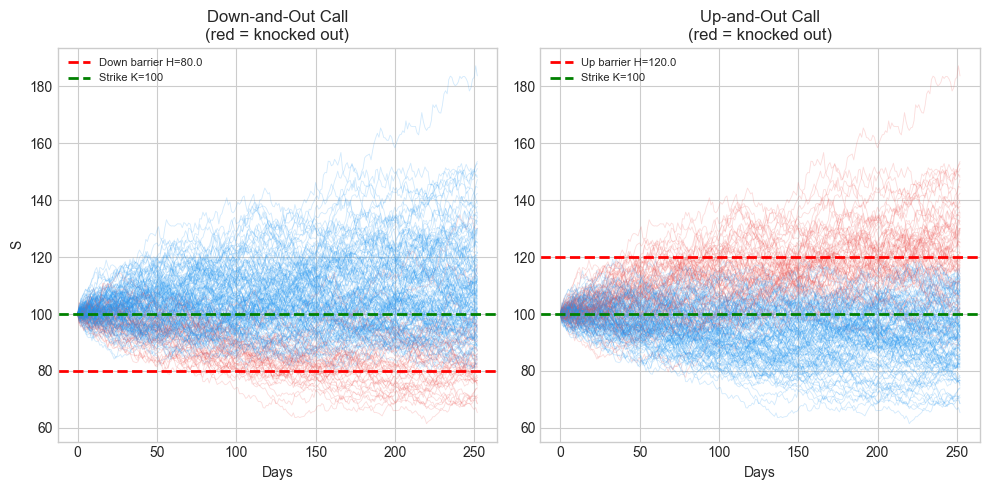

In [ ]:
# --- Barrier Options: Monte Carlo ---
S0=100
K=100
T=1.
r=0.03
sigma=0.20
N=100000
steps=252

H_down = 80.0   # down barrier
H_up   = 120.0  # up barrier

paths = simulate_gbm(S0, r, sigma, T, steps, N)
S_T   = paths[:, -1]
S_min = paths.min(axis=1)
S_max = paths.max(axis=1)

vanilla_call  = np.exp(-r*T) * np.mean(np.maximum(S_T - K, 0))

# Down-and-Out Call
dao_payoff = np.maximum(S_T - K, 0) * (S_min > H_down)
dao_price  = np.exp(-r*T) * np.mean(dao_payoff)

# Down-and-In Call
dai_payoff = np.maximum(S_T - K, 0) * (S_min <= H_down)
dai_price  = np.exp(-r*T) * np.mean(dai_payoff)

# Up-and-Out Call
uao_payoff = np.maximum(S_T - K, 0) * (S_max < H_up)
uao_price  = np.exp(-r*T) * np.mean(uao_payoff)

# Up-and-In Call
uai_payoff = np.maximum(S_T - K, 0) * (S_max >= H_up)
uai_price  = np.exp(-r*T) * np.mean(uai_payoff)

print(f'Vanilla Call      : {vanilla_call:.4f}')
print(f'Down-and-Out Call : {dao_price:.4f}  (barrier H={H_down})')
print(f'Down-and-In  Call : {dai_price:.4f}  (barrier H={H_down})')
print(f'Parity check DO+DI: {dao_price+dai_price:.4f}  (should equal vanilla)')
print(f'Up-and-Out   Call : {uao_price:.4f}  (barrier H={H_up})')
print(f'Up-and-In    Call : {uai_price:.4f}  (barrier H={H_up})')
print(f'Parity check UO+UI: {uao_price+uai_price:.4f}  (should equal vanilla)')

# Visualise barrier paths
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
colours_dao = ['#2196F3' if m > H_down else '#EF5350' for m in S_min[:200]]
for i in range(200):
    axes[0].plot(paths[i], alpha=0.2, lw=0.6, color=colours_dao[i])
axes[0].axhline(H_down, color='red',   lw=2, linestyle='--', label=f'Down barrier H={H_down}')
axes[0].axhline(K,      color='green', lw=2, linestyle='--', label=f'Strike K={K}')
axes[0].set_title('Down-and-Out Call\n(red = knocked out)')
axes[0].set_xlabel('Days'); axes[0].set_ylabel('S'); axes[0].legend(fontsize=8)

colours_uao = ['#2196F3' if m < H_up else '#EF5350' for m in S_max[:200]]
for i in range(200):
    axes[1].plot(paths[i], alpha=0.2, lw=0.6, color=colours_uao[i])
axes[1].axhline(H_up, color='red',   lw=2, linestyle='--', label=f'Up barrier H={H_up}')
axes[1].axhline(K,    color='green', lw=2, linestyle='--', label=f'Strike K={K}')
axes[1].set_title('Up-and-Out Call\n(red = knocked out)')
axes[1].set_xlabel('Days'); axes[1].legend(fontsize=8)
plt.tight_layout(); 
print('Done.')

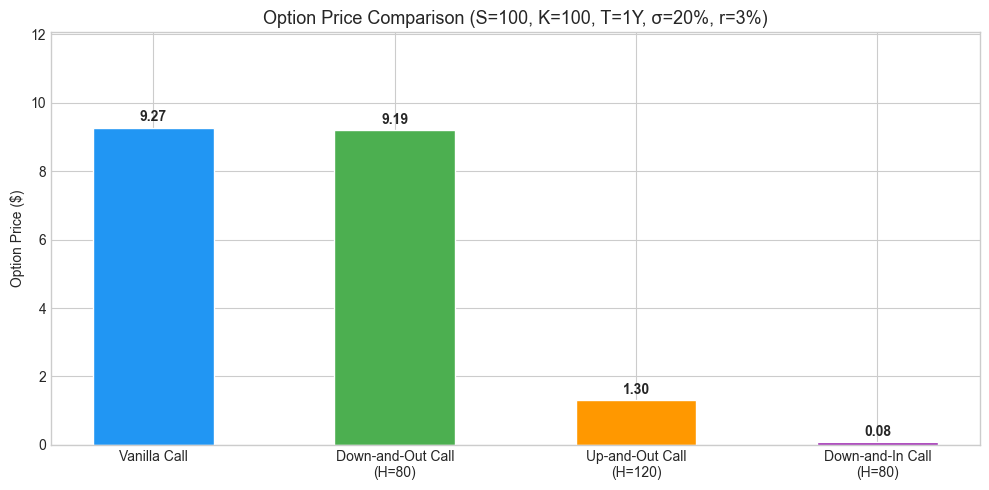

In [ ]:
# --- Final Summary Chart: Price comparison across products ---
products = [
    'Vanilla Call',
    'Down-and-Out Call\n(H=80)',
    'Up-and-Out Call\n(H=120)',
    'Down-and-In Call\n(H=80)',
]

paths_final = simulate_gbm(S0, r, sigma, T, steps, N)
S_T_f = paths_final[:, -1]
S_min_f = paths_final.min(axis=1)
S_max_f = paths_final.max(axis=1)

p_vanilla = np.exp(-r*T) * np.mean(np.maximum(S_T_f - K, 0))
p_dao     = np.exp(-r*T) * np.mean(np.maximum(S_T_f - K, 0) * (S_min_f > 80))
p_uao     = np.exp(-r*T) * np.mean(np.maximum(S_T_f - K, 0) * (S_max_f < 120))
p_dai     = np.exp(-r*T) * np.mean(np.maximum(S_T_f - K, 0) * (S_min_f <= 80))

prices_bar = [p_vanilla, p_dao, p_uao, p_dai]
colours_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(products, prices_bar, color=colours_bar, edgecolor='white', width=0.5)
for bar, price in zip(bars, prices_bar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{price:.2f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Option Price Comparison (S=100, K=100, T=1Y, σ=20%, r=3%)', fontsize=13)
ax.set_ylabel('Option Price ($)')
ax.set_ylim(0, p_vanilla * 1.3)
plt.tight_layout(); 

## 9. Asian Options

Asian options have payoffs that depend on the **average price** of the underlying 
over the life of the option rather than the terminal price $S_T$. This averaging 
makes them cheaper than vanilla options and naturally suited to situations where 
the average price over a period matters more than the price at a single point, 
such as commodities and FX hedging.

Let $\bar{S} = \frac{1}{n}\sum_{i=1}^{n} S_{t_i}$ be the discrete arithmetic 
average of the underlying over $n$ observation dates $t_1, \ldots, t_n = T$.

### 9.1.  Average Price (Fixed Strike)

The strike is fixed at $K$ and the average replaces the terminal price:

$$\text{Payoff}_{\text{call}} = \max(\bar{S} - K,\ 0)$$
$$\text{Payoff}_{\text{put}} = \max(K - \bar{S},\ 0)$$

**Finance application**: commodities and energy markets. A refinery buying oil 
continuously cares about the average price paid over a month, not the spot price 
on one day. The average price option hedges exactly this exposure and is harder 
to manipulate than a vanilla option whose payoff depends on a single fixing.

### 9.2.  Average Strike (Floating Strike)

The strike is the average itself and the payoff is relative to the terminal price:

$$\text{Payoff}_{\text{call}} = \max(S_T - \bar{S},\ 0)$$
$$\text{Payoff}_{\text{put}} = \max(\bar{S} - S_T,\ 0)$$

**Finance application**: FX hedging over a period. A multinational converting 
foreign revenues daily over a quarter wants to hedge the average rate achieved, 
not a single fixing. The average strike option pays the difference between the 
final rate and the average rate realized, which is exactly the hedging objective.

**Pricing**

There is no exact closed form for arithmetic Asian options because the sum of 
log-normal random variables is not log-normal. In practice:

- **Geometric average**: exact closed form exists since the product of log-normals 
  is log-normal, used as a control variate
- **Arithmetic average**: Monte Carlo with the geometric Asian as control variate, 
  or moment-matching approximations (Turnbull-Wakeman)

$$\bar{S}_{\text{geo}} = \left(\prod_{i=1}^{n} S_{t_i}\right)^{1/n} = 
\exp\left(\frac{1}{n}\sum_{i=1}^{n} \ln S_{t_i}\right)$$

**Key property**

Averaging reduces volatility. The effective volatility of $\bar{S}$ is 
approximately $\sigma/\sqrt{3}$ for a uniformly sampled arithmetic average 
under GBM, making Asian options significantly cheaper than vanilla options 
with the same strike and maturity.

Vanilla call price          : 9.4134
Geometric Asian call (exact): 5.0813
Arithmetic Asian (avg price): 5.2770 +/- 0.0021
Arithmetic Asian (avg strike): 4.9066 +/- 0.0019


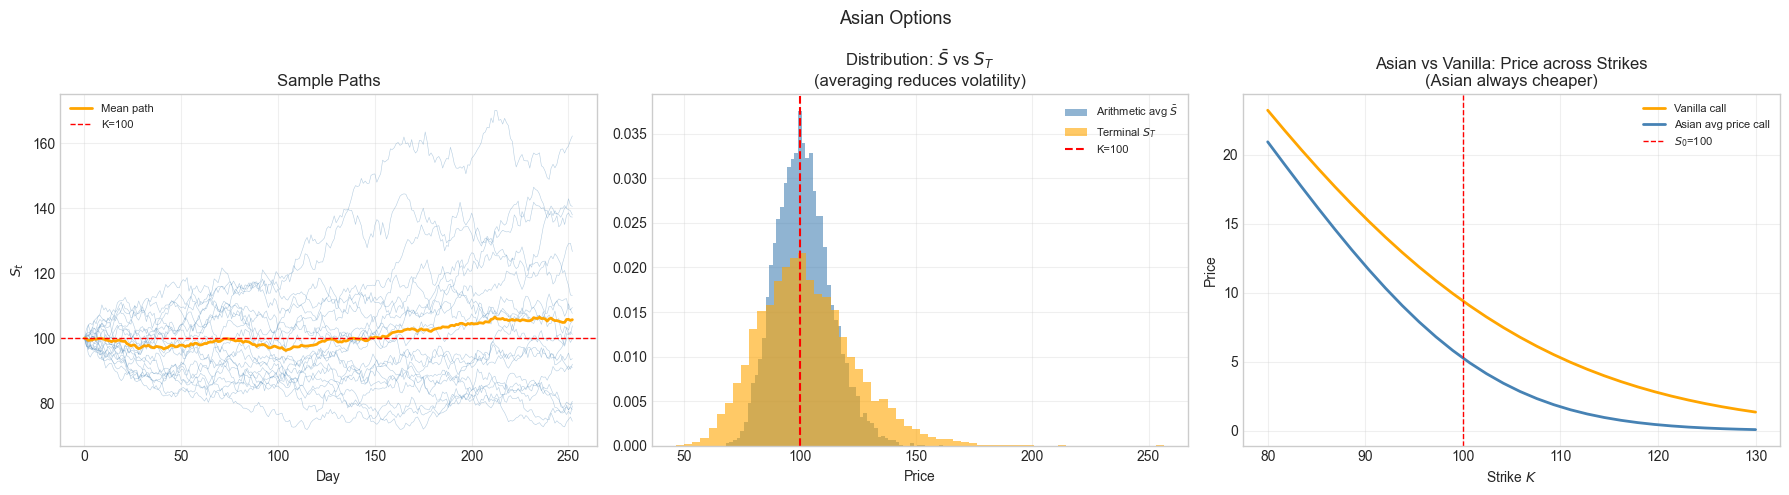

In [ ]:
# --- Asian Options ---

def geometric_asian_call(S, K, T, r, sigma, n):
    """Exact closed form for geometric average Asian call."""
    sigma_g = sigma * np.sqrt((2*n + 1) / (6*(n + 1)))
    b       = 0.5 * (r - 0.5 * sigma**2 + sigma_g**2)
    d1      = (np.log(S/K) + (b + 0.5*sigma_g**2)*T) / (sigma_g*np.sqrt(T))
    d2      = d1 - sigma_g*np.sqrt(T)
    return np.exp(-r*T) * (S * np.exp(b*T) * norm.cdf(d1) - K * norm.cdf(d2))

def simulate_asian(S0, K, T, r, sigma, n_steps, N_paths, option_type='average_price', 
                   flag='call', seed=42):
    """
    Monte Carlo pricing for arithmetic Asian options.
    option_type: 'average_price' (fixed strike) or 'average_strike' (floating strike)
    Uses geometric Asian as control variate for variance reduction.
    """
    np.random.seed(seed)
    dt      = T / n_steps
    paths   = np.zeros((N_paths, n_steps + 1))
    paths[:,0] = S0

    Z = np.random.standard_normal((N_paths, n_steps))
    for t in range(1, n_steps + 1):
        paths[:,t] = paths[:,t-1] * np.exp(
            (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:,t-1]
        )

    arith_avg = paths[:,1:].mean(axis=1)
    geo_avg   = np.exp(np.log(paths[:,1:]).mean(axis=1))
    S_T       = paths[:,-1]

    # payoffs
    if option_type == 'average_price':
        if flag == 'call':
            payoff_arith = np.maximum(arith_avg - K, 0)
            payoff_geo   = np.maximum(geo_avg   - K, 0)
        else:
            payoff_arith = np.maximum(K - arith_avg, 0)
            payoff_geo   = np.maximum(K - geo_avg,   0)
    else:  # average_strike
        if flag == 'call':
            payoff_arith = np.maximum(S_T - arith_avg, 0)
            payoff_geo   = np.maximum(S_T - geo_avg,   0)
        else:
            payoff_arith = np.maximum(arith_avg - S_T, 0)
            payoff_geo   = np.maximum(geo_avg   - S_T, 0)

    # control variate
    geo_exact  = geometric_asian_call(S0, K, T, r, sigma, n_steps)
    c          = np.cov(payoff_arith, payoff_geo)[0,1] / np.var(payoff_geo)
    cv_payoff  = payoff_arith - c * (payoff_geo - geo_exact * np.exp(r*T))
    price      = np.exp(-r*T) * cv_payoff.mean()
    se         = np.exp(-r*T) * cv_payoff.std() / np.sqrt(N_paths)
    return price, se, paths, arith_avg

# Parameters
n_steps  = 252
N_paths  = 10000

price_ap, se_ap, paths, arith_avg = simulate_asian(
    S0, K, T, r, sigma, n_steps, N_paths, 'average_price', 'call')
price_as, se_as, _, _             = simulate_asian(
    S0, K, T, r, sigma, n_steps, N_paths, 'average_strike', 'call')
vanilla                            = bsm_price(S0, K, T, r, sigma, 'call')
geo_exact                          = geometric_asian_call(S0, K, T, r, sigma, n_steps)

print(f'Vanilla call price          : {vanilla:.4f}')
print(f'Geometric Asian call (exact): {geo_exact:.4f}')
print(f'Arithmetic Asian (avg price): {price_ap:.4f} +/- {se_ap:.4f}')
print(f'Arithmetic Asian (avg strike): {price_as:.4f} +/- {se_as:.4f}')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Asian Options', fontsize=13)

# Panel 1: sample paths and their averages
for i in range(20):
    axes[0].plot(paths[i], color='steelblue', lw=0.4, alpha=0.4)
axes[0].plot(paths[:20].mean(axis=0), color='orange', lw=2, label='Mean path')
axes[0].axhline(K, color='red', lw=1, ls='--', label=f'K={K}')
axes[0].set_title('Sample Paths')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('$S_t$')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2: distribution of arithmetic average vs S_T
axes[1].hist(arith_avg, bins=60, color='steelblue', alpha=0.6, 
             density=True, label='Arithmetic avg $\\bar{S}$')
axes[1].hist(paths[:,-1], bins=60, color='orange', alpha=0.6, 
             density=True, label='Terminal $S_T$')
axes[1].axvline(K, color='red', lw=1.5, ls='--', label=f'K={K}')
axes[1].set_title('Distribution: $\\bar{S}$ vs $S_T$\n(averaging reduces volatility)')
axes[1].set_xlabel('Price')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: price comparison across strikes
strikes   = np.linspace(80, 130, 30)
vanilla_p = [bsm_price(S0, k, T, r, sigma, 'call') for k in strikes]
asian_p   = [simulate_asian(S0, k, T, r, sigma, n_steps, N_paths, 
                             'average_price', 'call', seed=42)[0] for k in strikes]

axes[2].plot(strikes, vanilla_p, color='orange',    lw=2, label='Vanilla call')
axes[2].plot(strikes, asian_p,   color='steelblue', lw=2, label='Asian avg price call')
axes[2].axvline(S0, color='red', lw=1, ls='--', label=f'$S_0$={S0:.0f}')
axes[2].set_title('Asian vs Vanilla: Price across Strikes\n(Asian always cheaper)')
axes[2].set_xlabel('Strike $K$')
axes[2].set_ylabel('Price')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Lookback Options

Lookback options have payoffs that depend on the **maximum or minimum** price 
realized by the underlying over the life of the option. They give the holder 
the benefit of hindsight: the ability to look back over the path and select 
the most favorable price.

Let:
$$M_T = \max_{0 \leq t \leq T} S_t, \qquad m_T = \min_{0 \leq t \leq T} S_t$$

## 10.1. Fixed Strike

The strike is fixed at $K$ and the payoff uses the realized maximum or minimum:

$$\text{Payoff}_{\text{call}} = \max(M_T - K,\ 0)$$
$$\text{Payoff}_{\text{put}} = \max(K - m_T,\ 0)$$

The call pays the difference between the **highest price ever reached** and 
the strike. The put pays the difference between the strike and the **lowest 
price ever reached**.

**Finance application**: a fixed strike lookback call lets the holder buy at 
the realized minimum relative to a fixed strike. Used when the investor wants 
to guarantee entry at the best price over a period.

## 10.2. Floating Strike

The strike is itself the realized extremum, and the payoff is relative to the 
terminal price:

$$\text{Payoff}_{\text{call}} = S_T - m_T$$
$$\text{Payoff}_{\text{put}} = M_T - S_T$$

The call pays the difference between the terminal price and the **realized 
minimum**: equivalent to having bought at the lowest price. The put pays the 
difference between the **realized maximum** and the terminal price: equivalent 
to having sold at the highest price.

**Finance application**: the floating strike lookback call captures the maximum 
realized return over the period, as if the holder had bought at the perfect 
bottom. Used in structured products promising to capture the best entry point.

**Closed-Form BSM Prices**

For the **floating strike lookback call** (assuming $S_0 = m_0$, i.e. no 
prior minimum):

$$C_{\text{float}} = S_0 \mathcal{N}(a_1) - S_0 \frac{\sigma^2}{2r}
\mathcal{N}(-a_1) - S_0 e^{-rT}\left(\mathcal{N}(a_2) - 
\frac{\sigma^2}{2r}\mathcal{N}(-a_2)\right)$$

where:
$$a_1 = \frac{(r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, 
\qquad a_2 = a_1 - \sigma\sqrt{T}$$

For the **fixed strike lookback call**:

$$C_{\text{fixed}} = C_{\text{BSM}}(S_0, K, T, r, \sigma) + 
S_0 e^{-rT}\frac{\sigma^2}{2r}\left[\left(\frac{S_0}{K}\right)^{-2r/\sigma^2}
\mathcal{N}(b_1) - e^{rT}\mathcal{N}(b_2)\right]$$

where:
$$b_1 = \frac{\ln(K/S_0) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, 
\qquad b_2 = b_1 - \sigma\sqrt{T}$$

**Key property**

Lookback options are the **most expensive** of all standard path-dependent 
options because they always give the holder the best possible outcome in 
hindsight. They are significantly more expensive than vanilla options and 
even Asian options.

Vanilla call                    : 9.4134
Lookback float call (MC)        : 15.5912 +/- 0.1394
Lookback float call (exact)     : 13.7187
Lookback fixed strike call (MC) : 17.2392 +/- 0.1484


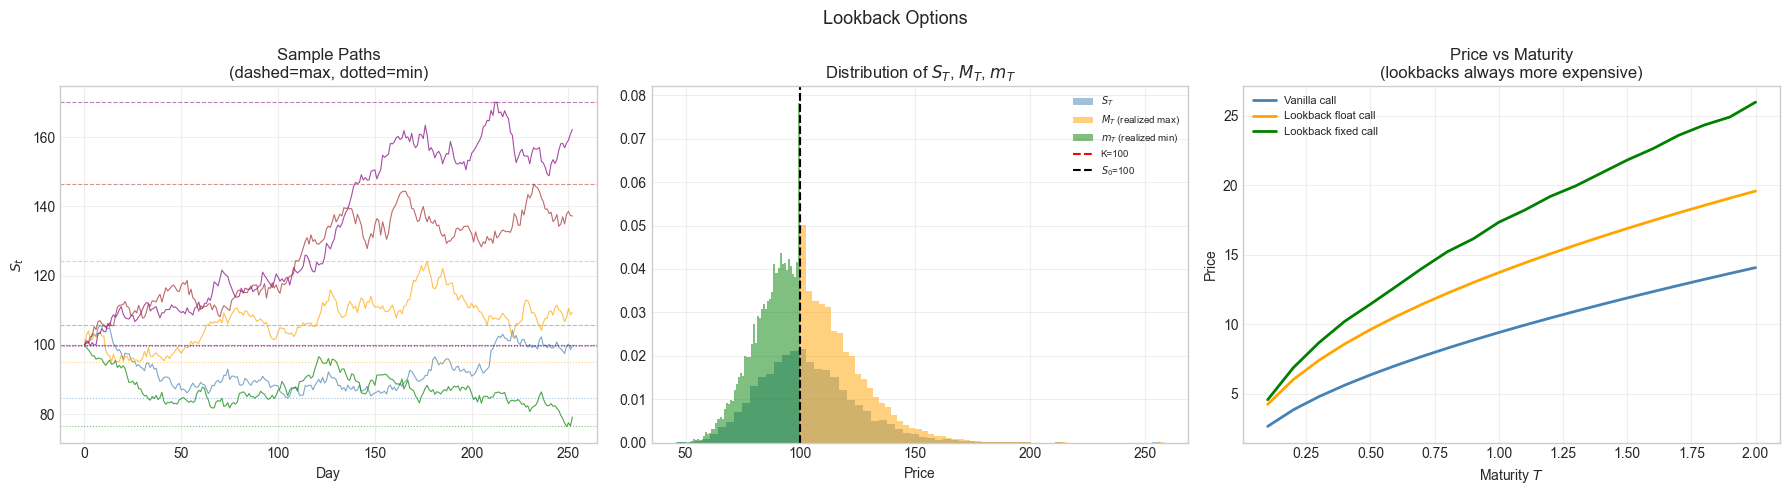

In [ ]:
# --- Lookback Options ---

def lookback_float_call_exact(S, T, r, sigma):
    """Exact BSM price for floating strike lookback call."""
    a1 = (r + 0.5*sigma**2)*T / (sigma*np.sqrt(T))
    a2 = a1 - sigma*np.sqrt(T)
    term1 = S * norm.cdf(a1)
    term2 = S * (sigma**2/(2*r)) * norm.cdf(-a1)
    term3 = S * np.exp(-r*T) * (norm.cdf(a2) - (sigma**2/(2*r))*norm.cdf(-a2))
    return term1 - term2 - term3

def simulate_lookback(S0, K, T, r, sigma, n_steps, N_paths, 
                      option_type='float', flag='call', seed=42):
    """Monte Carlo for lookback options."""
    np.random.seed(seed)
    dt    = T / n_steps
    paths = np.zeros((N_paths, n_steps + 1))
    paths[:,0] = S0

    Z = np.random.standard_normal((N_paths, n_steps))
    for t in range(1, n_steps + 1):
        paths[:,t] = paths[:,t-1] * np.exp(
            (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:,t-1]
        )

    M_T = paths.max(axis=1)   # realized maximum
    m_T = paths.min(axis=1)   # realized minimum
    S_T = paths[:,-1]

    if option_type == 'float':
        if flag == 'call':
            payoff = S_T - m_T        # bought at realized minimum
        else:
            payoff = M_T - S_T        # sold at realized maximum
    else:  # fixed strike
        if flag == 'call':
            payoff = np.maximum(M_T - K, 0)
        else:
            payoff = np.maximum(K - m_T, 0)

    price = np.exp(-r*T) * payoff.mean()
    se    = np.exp(-r*T) * payoff.std() / np.sqrt(N_paths)
    return price, se, paths, M_T, m_T

# Pricing
n_steps = 252
N_paths = 10000

price_float, se_float, paths, M_T, m_T = simulate_lookback(
    S0, K, T, r, sigma, n_steps, N_paths, 'float', 'call')
price_fixed, se_fixed, _, _, _          = simulate_lookback(
    S0, K, T, r, sigma, n_steps, N_paths, 'fixed', 'call')
exact_float                             = lookback_float_call_exact(S0, T, r, sigma)
vanilla                                 = bsm_price(S0, K, T, r, sigma, 'call')

print(f'Vanilla call                    : {vanilla:.4f}')
print(f'Lookback float call (MC)        : {price_float:.4f} +/- {se_float:.4f}')
print(f'Lookback float call (exact)     : {exact_float:.4f}')
print(f'Lookback fixed strike call (MC) : {price_fixed:.4f} +/- {se_fixed:.4f}')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Lookback Options', fontsize=13)

# Panel 1: sample paths with max and min highlighted
n_show = 5
colors_paths = ['steelblue', 'orange', 'green', 'purple', 'brown']
for i in range(n_show):
    axes[0].plot(paths[i], color=colors_paths[i], lw=0.8, alpha=0.7)
    axes[0].axhline(M_T[i], color=colors_paths[i], lw=0.8, ls='--', alpha=0.5)
    axes[0].axhline(m_T[i], color=colors_paths[i], lw=0.8, ls=':',  alpha=0.5)
axes[0].set_title('Sample Paths\n(dashed=max, dotted=min)')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('$S_t$')
axes[0].grid(True, alpha=0.3)

# Panel 2: distribution of M_T and m_T vs S_T
axes[1].hist(paths[:,-1], bins=60, color='steelblue', alpha=0.5, 
             density=True, label='$S_T$')
axes[1].hist(M_T, bins=60, color='orange', alpha=0.5, 
             density=True, label='$M_T$ (realized max)')
axes[1].hist(m_T, bins=60, color='green',  alpha=0.5, 
             density=True, label='$m_T$ (realized min)')
axes[1].axvline(K,  color='red',   lw=1.5, ls='--', label=f'K={K}')
axes[1].axvline(S0, color='black', lw=1.5, ls='--', label=f'$S_0$={S0}')
axes[1].set_title('Distribution of $S_T$, $M_T$, $m_T$')
axes[1].set_xlabel('Price')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# Panel 3: price comparison across maturities
maturities  = np.linspace(0.1, 2.0, 20)
vanilla_p   = [bsm_price(S0, K, t, r, sigma, 'call') for t in maturities]
float_exact = [lookback_float_call_exact(S0, t, r, sigma) for t in maturities]
fixed_mc    = [simulate_lookback(S0, K, t, r, sigma, 
                                  int(252*t), N_paths, 'fixed', 'call')[0] 
               for t in maturities]

axes[2].plot(maturities, vanilla_p,   color='steelblue', lw=2, label='Vanilla call')
axes[2].plot(maturities, float_exact, color='orange',    lw=2, label='Lookback float call')
axes[2].plot(maturities, fixed_mc,    color='green',     lw=2, label='Lookback fixed call')
axes[2].set_title('Price vs Maturity\n(lookbacks always more expensive)')
axes[2].set_xlabel('Maturity $T$')
axes[2].set_ylabel('Price')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 11. Accumulators

An accumulator is a forward contract where the client agrees to **buy a fixed number of shares per day at a discount to the current spot price** for a fixed period (typically one year).

- If the stock rises above a **knock-out level** $H_{KO}$, the contract terminates and the client stops accumulating.
- If the stock falls below a **double-up level** $H_{DU}$, the client must accumulate **twice the daily quantity** at the same discounted price.
- Known as *I Kill You Later* in Asian private banking.

<small> 

| Parameter | Typical value |
|-----------|---------------|
| Forward price | $F = S_0 \times (1 - \text{discount})$, e.g. 5% below spot |
| Knock-out $H_{KO}$ | e.g. $S_0 \times 1.05$ (5% above spot) |
| Double-up $H_{DU}$ | e.g. $S_0 \times 0.90$ (10% below spot) |
| Daily shares | $n$ shares per business day |
| Tenor | 252 business days (1 year) |

</small> 

#### Daily P&L for the client

On each business day $t$:

$$\text{P\&L}_t = \begin{cases}
n \cdot (S_t - F) & \text{if } H_{DU} < S_t < H_{KO} \text{ (normal)} \\
2n \cdot (S_t - F) & \text{if } S_t \leq H_{DU} \text{ (double-up, painful)} \\
0 & \text{if } S_t \geq H_{KO} \text{ (knocked out, contract ends)}
\end{cases}$$

#### Pricing

The accumulator is priced as a strip of **daily forward contracts** with embedded barrier features. Under GBM the total value is:

$$V_0 = \sum_{t=1}^{T} e^{-r t/252} \cdot \mathbb{E}^Q\left[\text{P\&L}_t \cdot \mathbf{1}\{\text{active at } t\}\right]$$

The discount on $F$ is set so that $V_0 = 0$ (zero-cost structure for the client).

Accumulator forward price F = 95.0 (discount=5% on S0=100)
Knock-out at H_KO = 105.0, Double-up at H_DU = 90.0

Client Mean Total P&L   : -84,354
Client P&L Std Dev      : 211,988
Client P&L 5th pctile   : -592,227  (tail risk)
Mean shares accumulated : 13,391
Prob of loss for client : 29.3%
Done.


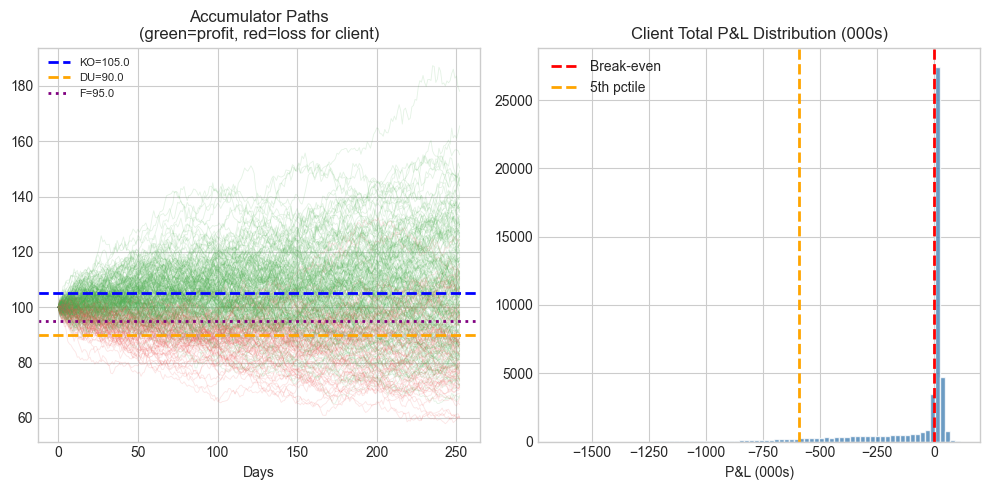

In [ ]:
# --- Accumulator Monte Carlo ---
H_KO    = 105.0   # knock-out: contract ends if S >= 105
H_DU    = 90.0    # double-up: client accumulates 2x if S <= 90
n       = 100     # shares per day
discount = 0.05   # 5% discount
F_acc   = S0 * (1 - discount)  # forward price = 95

print(f'Accumulator forward price F = {F_acc:.1f} (discount={discount*100:.0f}% on S0={S0})')
print(f'Knock-out at H_KO = {H_KO}, Double-up at H_DU = {H_DU}')

n_paths_acc = 50000
paths_acc = simulate_gbm(S0, r - q, sigma, T, steps, n_paths_acc)

total_pnl = np.zeros(n_paths_acc)
total_shares = np.zeros(n_paths_acc)

for path_idx in range(n_paths_acc):
    path = paths_acc[path_idx]
    active = True
    pnl = 0.0
    shares = 0.0
    for day in range(1, steps + 1):
        if not active:
            break
        S_t = path[day]
        disc = np.exp(-r * day / 252)
        if S_t >= H_KO:
            active = False  # knocked out
        elif S_t <= H_DU:
            # double up
            daily_pnl = 2 * n * (S_t - F_acc)
            pnl += disc * daily_pnl
            shares += 2 * n
        else:
            daily_pnl = n * (S_t - F_acc)
            pnl += disc * daily_pnl
            shares += n
    total_pnl[path_idx]    = pnl
    total_shares[path_idx] = shares

print(f'\nClient Mean Total P&L   : {np.mean(total_pnl):,.0f}')
print(f'Client P&L Std Dev      : {np.std(total_pnl):,.0f}')
print(f'Client P&L 5th pctile   : {np.percentile(total_pnl,5):,.0f}  (tail risk)')
print(f'Mean shares accumulated : {np.mean(total_shares):,.0f}')
print(f'Prob of loss for client : {(total_pnl < 0).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Sample paths coloured by outcome
for i in range(300):
    color = '#EF5350' if total_pnl[i] < 0 else '#4CAF50'
    axes[0].plot(paths_acc[i], alpha=0.15, lw=0.6, color=color)
axes[0].axhline(H_KO, color='blue',   lw=2, linestyle='--', label=f'KO={H_KO}')
axes[0].axhline(H_DU, color='orange', lw=2, linestyle='--', label=f'DU={H_DU}')
axes[0].axhline(F_acc, color='purple', lw=2, linestyle=':', label=f'F={F_acc}')
axes[0].set_title('Accumulator Paths\n(green=profit, red=loss for client)')
axes[0].set_xlabel('Days'); axes[0].legend(fontsize=8)

axes[1].hist(total_pnl / 1000, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=2, linestyle='--', label='Break-even')
axes[1].axvline(np.percentile(total_pnl, 5) / 1000, color='orange',
                lw=2, linestyle='--', label='5th pctile')
axes[1].set_title('Client Total P&L Distribution (000s)')
axes[1].set_xlabel('P&L (000s)'); axes[1].legend()
plt.tight_layout(); 
print('Done.')

### Accumulator vs Short Straddle

The accumulator shares the **short volatility** character of a short straddle: 
both positions are hurt in both tails and profit in calm, low-volatility markets. 
However there are important structural differences.

A short straddle is:
- short a call at strike $K$
- short a put at strike $K$

The accumulator embeds implicitly:
- short a put: client keeps buying at fixed price regardless of how far stock falls
- short a knock-out call: contract terminates if stock rises above barrier $H$

<small> 

| | Short Straddle | Accumulator |
|---|---|---|
| Downside loss | Linear in put | Convex due to double-up clause |
| Upside loss | Linear in call | Capped: contract terminates at $H$ |
| Premium received | Explicit upfront cash | Implicit via discount on forward |
| Symmetry | Symmetric around strike | Asymmetric: knock-out only on upside |
| Obligation | No obligation to buy stock | Forced to buy stock daily |
| Liquidity | Can be unwound in market | OTC, very hard to unwind |

</small> 

The downside of the accumulator is **worse** than a straddle because the double-up 
clause makes losses convex: the further the stock falls, the faster losses accelerate. 
The upside loss is **softer** because the contract simply stops rather than continuing 
to bleed. The most dangerous feature is the physical obligation to buy stock daily, 
which a short straddle never imposes.

---
## 11. Decumulators

The **mirror image of an accumulator**. The client agrees to **sell shares at a premium to current spot price** every day for a fixed period. Used by clients who want to exit a large concentrated equity position gradually at a favourable price.

**Use case**: Corporate insiders, family offices, controlling shareholders who want to monetise a position without selling at market in one block.

- **stock stays near $F(1+p)$**: client sells above market, collects premium. 
  Works as intended.
- **stock falls below $H_{down}$**: knock-out triggers, contract terminates. 
  Client loses the premium stream precisely when holding stock is painful.
- **stock rises above $F(1+p)$**: double-down triggers, client forced to sell 
  twice the daily quantity at $F(1+p)$, which is below market. Client gives 
  up twice the upside into a rising market.

<small> 

| Parameter | Value |
|-----------|-------|
| Sale price | $F = S_0 \times (1 + \text{premium})$, e.g. 5% above spot |
| Knock-out $H_{KO}$ | e.g. $S_0 \times 0.95$ (stock falls 5%, contract ends) |
| Double-up $H_{DU}$ | e.g. $S_0 \times 1.10$ (stock rises 10%, sell 2x) |
</small> 

#### Daily P&L for the client (seller)

$$\text{P\&L}_t = \begin{cases}
n \cdot (F - S_t) & \text{if } H_{KO} < S_t < H_{DU} \text{ (normal, client sells above market)} \\
2n \cdot (F - S_t) & \text{if } S_t \geq H_{DU} \text{ (double-up, sells more but misses the rally)} \\
0 & \text{if } S_t \leq H_{KO} \text{ (knocked out)}
\end{cases}$$

**Key risk**: if the stock rallies strongly, the client must sell twice the quantity at the contracted price, forgoing the additional upside. The worst case is the stock rallies far above $H_{DU}$ and the client has sold most of their position at a price well below market.

Decumulator sale price F = 105.0 (premium=5% on S0=100)
Knock-out at H_KO = 95.0, Double-up at H_DU = 110.0

Client Mean P&L        : -106,069
Client P&L 5th pctile  : -744,231  (tail risk)
Prob of loss for client: 29.1%


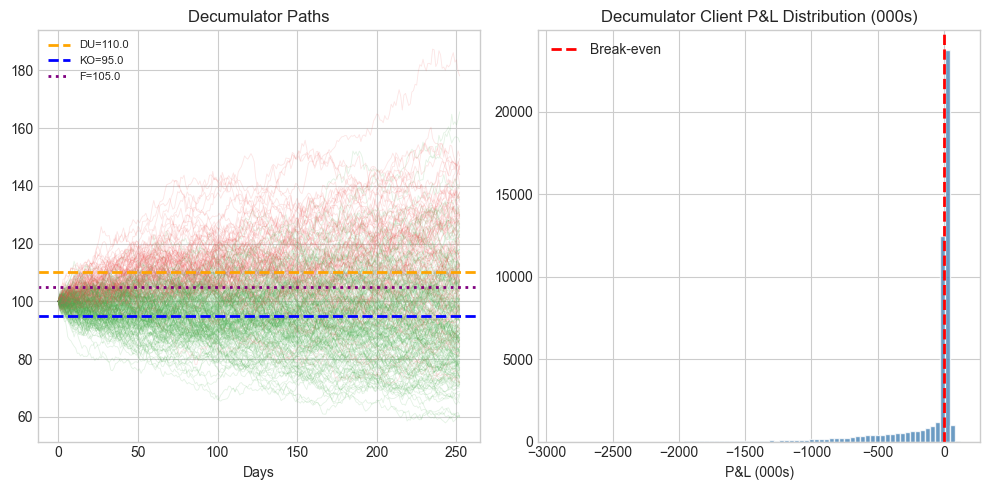

In [ ]:
# --- Decumulator Monte Carlo ---
H_KO_de  = 95.0    # knock-out if S falls below 95
H_DU_de  = 110.0   # double-up if S rises above 110
premium  = 0.05    # 5% premium on spot
F_dec    = S0 * (1 + premium)  # sale price = 105

print(f'Decumulator sale price F = {F_dec:.1f} (premium={premium*100:.0f}% on S0={S0})')
print(f'Knock-out at H_KO = {H_KO_de}, Double-up at H_DU = {H_DU_de}')

total_pnl_dec = np.zeros(n_paths_acc)

for path_idx in range(n_paths_acc):
    path = paths_acc[path_idx]
    active = True
    pnl = 0.0
    for day in range(1, steps + 1):
        if not active:
            break
        S_t = path[day]
        disc = np.exp(-r * day / 252)
        if S_t <= H_KO_de:
            active = False  # knocked out: stock fell, client stops selling
        elif S_t >= H_DU_de:
            pnl += disc * 2 * n * (F_dec - S_t)  # double-up: selling 2x, missing rally
        else:
            pnl += disc * n * (F_dec - S_t)       # normal: selling at premium to market
    total_pnl_dec[path_idx] = pnl

print(f'\nClient Mean P&L        : {np.mean(total_pnl_dec):,.0f}')
print(f'Client P&L 5th pctile  : {np.percentile(total_pnl_dec,5):,.0f}  (tail risk)')
print(f'Prob of loss for client: {(total_pnl_dec < 0).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
for i in range(300):
    color = '#4CAF50' if total_pnl_dec[i] >= 0 else '#EF5350'
    axes[0].plot(paths_acc[i], alpha=0.15, lw=0.6, color=color)
axes[0].axhline(H_DU_de, color='orange', lw=2, linestyle='--', label=f'DU={H_DU_de}')
axes[0].axhline(H_KO_de, color='blue',   lw=2, linestyle='--', label=f'KO={H_KO_de}')
axes[0].axhline(F_dec,   color='purple', lw=2, linestyle=':',  label=f'F={F_dec}')
axes[0].set_title('Decumulator Paths')
axes[0].set_xlabel('Days'); axes[0].legend(fontsize=8)

axes[1].hist(total_pnl_dec / 1000, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=2, linestyle='--', label='Break-even')
axes[1].set_title('Decumulator Client P&L Distribution (000s)')
axes[1].set_xlabel('P&L (000s)'); axes[1].legend()
plt.tight_layout(); 

### Accumulator vs Decumulator Discussion

Risk Profile for the Client: Both structures appear attractive at inception: the accumulator offers shares 
at a discount, the decumulator offers above-market selling prices. In both cases 
the compensation is not free. The client is implicitly selling options to the 
issuer to fund the discount or premium.

**Accumulator: "I Kill You Later"**

The asymmetry is brutal on the downside. The knock-out on the upside 
($S_t > H_{up}$) protects the **issuer**: the contract terminates precisely 
when the client would benefit most from continued cheap buying. On the downside 
there is no such protection for the client:

- stock falls below $F(1-d)$: double-up triggers, client buys twice the 
  daily quantity at above-market prices
- stock keeps falling: contract keeps running, client keeps buying double 
  every single day, accumulating an ever larger long position in a falling stock
- there is no exit: the only termination event is on the upside, which never 
  comes in a crash

The client ends up holding a large position bought at prices well above market, 
with losses that are convex in the size of the drawdown. The deeper the crash, 
the faster losses accelerate.

**Decumulator: Capped Upside, Forced Exit on the Downside**

The risk profile is the mirror image but equally asymmetric:

- stock rises above $F(1+p)$: double-down triggers, client forced to sell 
  twice the daily quantity below market, giving up twice the upside
- stock falls below $H_{down}$: knock-out triggers, contract terminates. 
  The client loses the premium stream and is left holding stock in a 
  falling market with no further selling obligation to offset losses
- there is no protection: the termination event is on the downside, 
  removing the only mechanism that was generating above-market proceeds

<small> 

| | Accumulator | Decumulator |
|---|---|---|
| Knock-out protects | Issuer (upside) | Issuer (downside) |
| Double obligation hurts | Client (downside) | Client (upside) |
| Worst scenario | Prolonged crash, no exit | Strong rally, forced to sell cheap |
| Client left holding | Large long in falling market | Stock with no premium stream |
| Nickname | "I kill you later" | "I kill you faster" |

</small> 

In both cases the knock-out barrier protects the issuer, never the client. 
The discount or premium is the premium collected from selling this asymmetric 
risk to the issuer. Both structures are suitable only for clients with a 
strong directional conviction and a full understanding of the tail risk embedded 
in the double obligation clause.

## 12. Cliquet Option (Ratchet)

A cliquet option is a series of forward-starting options where the strike 
resets periodically to the current spot price, locking in gains at each 
reset date. The total payoff is the sum of periodic returns, each floored 
at zero (or a local floor $F$) and capped at a local cap $C$.

Let $0 = t_0 < t_1 < \cdots < t_n = T$ be the reset dates with equal spacing 
$\delta = t_i - t_{i-1}$. The local return at period $i$ is:

$$r_i = \frac{S_{t_i} - S_{t_{i-1}}}{S_{t_{i-1}}}$$

The **global payoff** is:

$$\text{Payoff} = \sum_{i=1}^{n} \min\left(C,\ \max(F,\ r_i)\right)$$

where $F$ is the local floor (typically $0$ or slightly negative) and $C$ 
is the local cap. Each period contributes independently, with gains locked 
in and losses floored.

**Special cases**

- **No cap, floor at zero**: $\text{Payoff} = \sum_{i=1}^n \max(r_i, 0)$, 
  a sum of at-the-money forward starting calls
- **Global floor**: an additional guarantee that the total payoff is at 
  least some minimum $G$, common in structured notes
- **Ratchet**: floor set to previous period gain, so losses in one period 
  cannot erode gains from prior periods

**Pricing**

Each local payoff $\min(C, \max(F, r_i))$ is a **capped and floored 
forward-starting call**, which can be decomposed as:

$$\min(C, \max(F, r_i)) = \max(F, r_i) - \max(r_i - C, 0)$$

a long floored return minus a short capped return. Under GBM each 
forward-starting option has a BSM closed form since $r_i$ is log-normal 
and independent of $S_{t_{i-1}}$. However the **correlation structure 
across periods** and the presence of **forward volatility** (the implied 
volatility of future reset options) makes calibration complex. Monte Carlo 
is the standard pricing method.

**Key risk: forward volatility**

The cliquet is primarily sensitive to **forward volatility** $\sigma(t_{i-1}, t_i)$, 
the implied volatility of options starting at future dates. This is distinct 
from spot volatility and requires a stochastic volatility model (Heston, SABR) 
to price correctly. A flat vol surface underprices cliquets significantly.

**Finance application**: cliquets are embedded in **structured notes** sold 
to retail investors, offering capital protection plus participation in periodic 
equity gains. Common in Europe and Asia as alternatives to direct equity exposure.

Cliquet price (% of notional): 20.0449% +/- 0.0315%
ATM vanilla call (% of spot) : 9.4134%
Average local return per period: 0.2426%
Average clipped return per period: 1.7213%


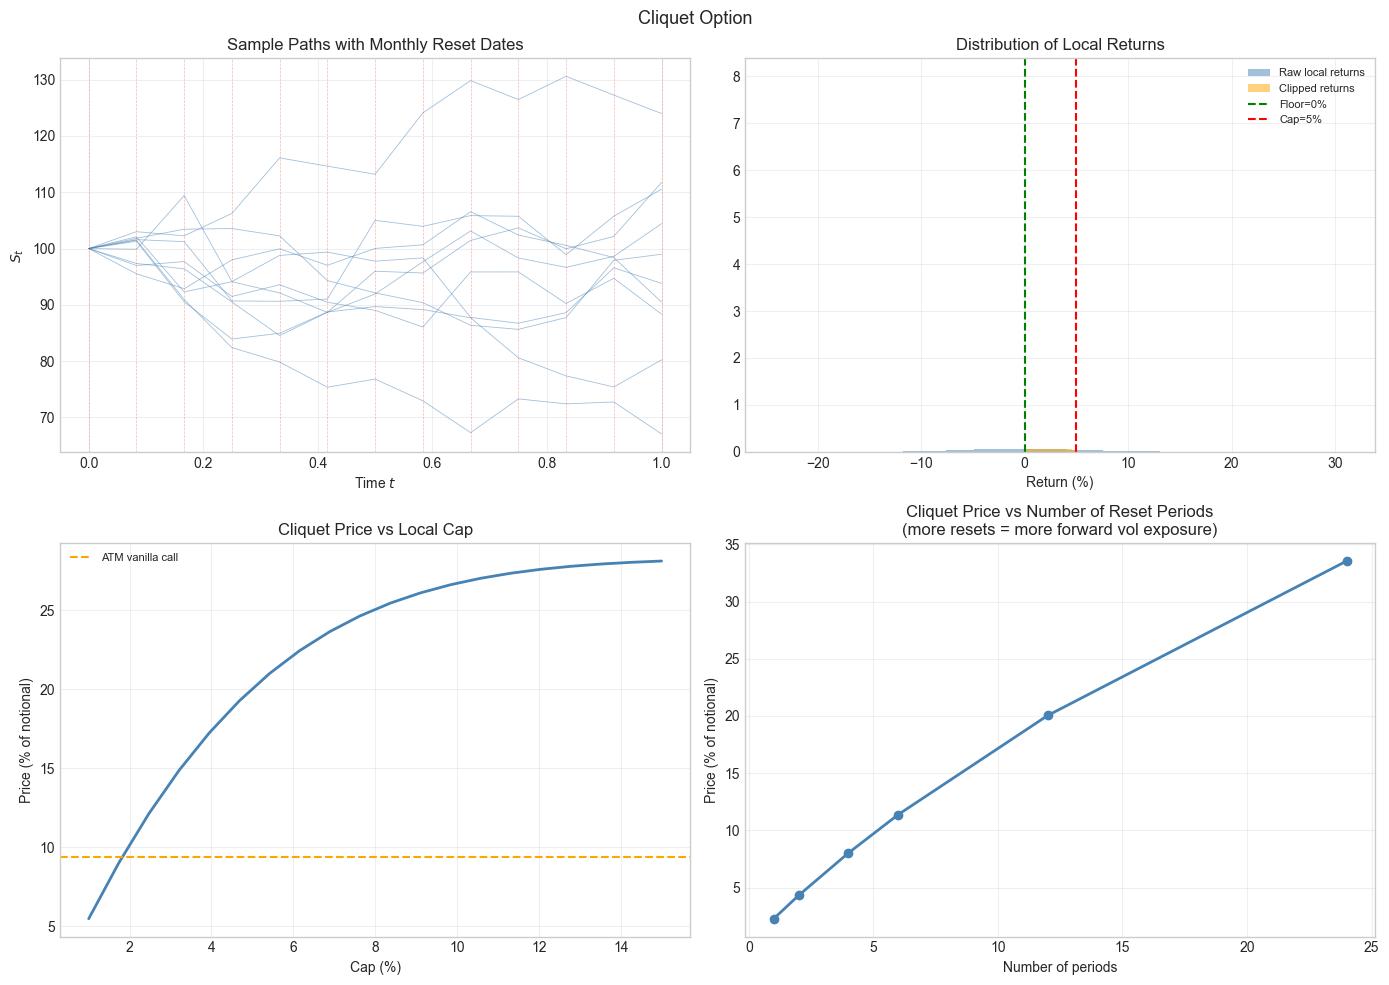

In [ ]:
# --- Cliquet Option ---

def simulate_cliquet(S0, T, r, sigma, n_periods, N_paths,
                     floor=0.0, cap=0.05, seed=42):
    """
    Monte Carlo for cliquet option.
    Returns price, se, all paths, and all local returns.
    """
    np.random.seed(seed)
    dt        = T / n_periods
    paths     = np.zeros((N_paths, n_periods + 1))
    paths[:,0] = S0

    Z = np.random.standard_normal((N_paths, n_periods))
    for t in range(1, n_periods + 1):
        paths[:,t] = paths[:,t-1] * np.exp(
            (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:,t-1]
        )

    # local returns
    local_returns = (paths[:,1:] - paths[:,:-1]) / paths[:,:-1]

    # apply floor and cap to each period
    clipped = np.clip(local_returns, floor, cap)

    # global payoff = sum of clipped returns
    payoff = clipped.sum(axis=1)
    price  = np.exp(-r*T) * payoff.mean()
    se     = np.exp(-r*T) * payoff.std() / np.sqrt(N_paths)
    return price, se, paths, local_returns, clipped

# Parameters
n_periods = 12      # monthly resets over 1 year
floor     = 0.0     # local floor: 0%
cap       = 0.05    # local cap: 5% per period
N_paths   = 50000

price, se, paths, local_ret, clipped = simulate_cliquet(
    S0, T, r, sigma, n_periods, N_paths, floor, cap)

# Compare with vanilla call of same maturity
vanilla = bsm_price(S0, S0, T, r, sigma, 'call') / S0  # ATM call as % of spot

print(f'Cliquet price (% of notional): {price*100:.4f}% +/- {se*100:.4f}%')
print(f'ATM vanilla call (% of spot) : {vanilla*100:.4f}%')
print(f'Average local return per period: {local_ret.mean()*100:.4f}%')
print(f'Average clipped return per period: {clipped.mean()*100:.4f}%')

# Sensitivity to cap level
caps      = np.linspace(0.01, 0.15, 20)
prices_cap = [simulate_cliquet(S0, T, r, sigma, n_periods, N_paths,
                                floor, c)[0] for c in caps]

# Sensitivity to number of periods
periods      = [1, 2, 4, 6, 12, 24]
prices_per   = [simulate_cliquet(S0, T, r, sigma, p, N_paths,
                                  floor, cap)[0] for p in periods]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cliquet Option', fontsize=13)

# Panel 1: sample paths with reset dates marked
n_show = 10
t_grid = np.linspace(0, T, n_periods + 1)
for i in range(n_show):
    axes[0,0].plot(t_grid, paths[i], color='steelblue', lw=0.6, alpha=0.5)
for t in t_grid:
    axes[0,0].axvline(t, color='red', lw=0.5, ls='--', alpha=0.3)
axes[0,0].set_title('Sample Paths with Monthly Reset Dates')
axes[0,0].set_xlabel('Time $t$')
axes[0,0].set_ylabel('$S_t$')
axes[0,0].grid(True, alpha=0.3)

# Panel 2: distribution of local returns vs clipped returns
axes[0,1].hist(local_ret.flatten()*100, bins=80, color='steelblue',
               alpha=0.5, density=True, label='Raw local returns')
axes[0,1].hist(clipped.flatten()*100,   bins=80, color='orange',
               alpha=0.5, density=True, label='Clipped returns')
axes[0,1].axvline(floor*100, color='green', lw=1.5, ls='--', label=f'Floor={floor*100:.0f}%')
axes[0,1].axvline(cap*100,   color='red',   lw=1.5, ls='--', label=f'Cap={cap*100:.0f}%')
axes[0,1].set_title('Distribution of Local Returns')
axes[0,1].set_xlabel('Return (%)')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# Panel 3: price vs cap level
axes[1,0].plot(np.array(caps)*100, np.array(prices_cap)*100,
               color='steelblue', lw=2)
axes[1,0].axhline(vanilla*100, color='orange', lw=1.5, ls='--',
                   label='ATM vanilla call')
axes[1,0].set_title('Cliquet Price vs Local Cap')
axes[1,0].set_xlabel('Cap (%)')
axes[1,0].set_ylabel('Price (% of notional)')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

# Panel 4: price vs number of reset periods
axes[1,1].plot(periods, np.array(prices_per)*100,
               color='steelblue', lw=2, marker='o', ms=6)
axes[1,1].set_title('Cliquet Price vs Number of Reset Periods\n(more resets = more forward vol exposure)')
axes[1,1].set_xlabel('Number of periods')
axes[1,1].set_ylabel('Price (% of notional)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Napoleon Option

A Napoleon option pays a guaranteed coupon plus the **sum of the worst 
periodic returns** over the life of the option. It is a yield enhancement 
product: the investor sacrifices the best returns in exchange for a guaranteed 
minimum coupon.

Let $0 = t_0 < t_1 < \cdots < t_n = T$ be monthly observation dates. 
The local return at period $i$ is:

$$r_i = \frac{S_{t_i} - S_{t_{i-1}}}{S_{t_{i-1}}}$$

The **global payoff** is:

$$\text{Payoff} = \text{Coupon} + \min_{i=1,\ldots,n} r_i$$

where $\min_{i=1,\ldots,n} r_i$ is the **worst monthly return** over the 
entire life. The coupon is fixed at inception and is the compensation for 
selling the best returns to the issuer.

**Comparison to Cliquet**
<small> 

| | Cliquet | Napoleon |
|---|---|---|
| Payoff | Sum of all clipped returns | Coupon + worst single return |
| Key risk | Forward volatility | Correlation + worst-of return |
| Investor view | Steady periodic gains | Yield enhancement, range-bound |
| Tail risk | Capped on each period | Worst month can dominate |

</small> 

**Key risk**

The Napoleon is short the **worst-of** monthly return. In a crash one very 
bad month can wipe out the entire coupon and generate a loss. The investor 
is essentially selling a put on the worst monthly performance, which is 
heavily influenced by **correlation** across time periods and **skew** in 
the return distribution.

**Finance application**: Napoleons are sold as yield enhancement structured 
notes to investors seeking above-market coupons in range-bound markets. 
The issuer embeds a short worst-of put to fund the coupon.

Napoleon price (% of notional): 0.7554% +/- 0.0057%
Average worst monthly return  : -8.8677%
Worst monthly return (5th pct): -14.0569%
Prob of positive payoff       : 40.64%


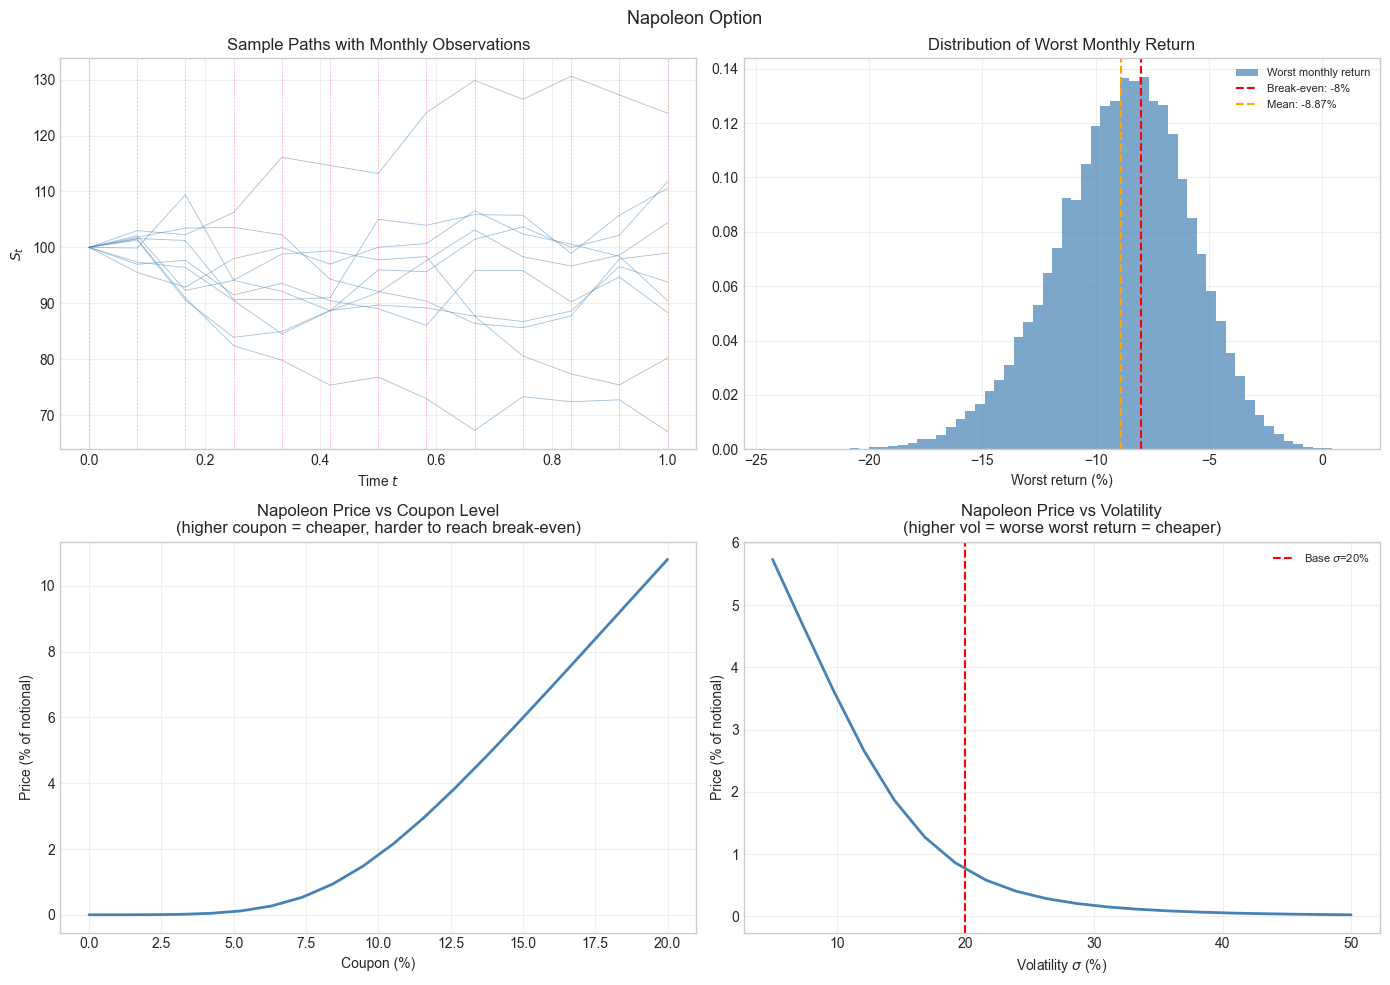

In [ ]:
# --- Napoleon Option ---

def simulate_napoleon(S0, T, r, sigma, n_periods, N_paths,
                      coupon=0.08, seed=42):
    """
    Monte Carlo for Napoleon option.
    Payoff = coupon + min(r_1, ..., r_n)
    """
    np.random.seed(seed)
    dt         = T / n_periods
    paths      = np.zeros((N_paths, n_periods + 1))
    paths[:,0] = S0

    Z = np.random.standard_normal((N_paths, n_periods))
    for t in range(1, n_periods + 1):
        paths[:,t] = paths[:,t-1] * np.exp(
            (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:,t-1]
        )

    local_returns = (paths[:,1:] - paths[:,:-1]) / paths[:,:-1]
    worst_return  = local_returns.min(axis=1)
    payoff        = np.maximum(coupon + worst_return, 0)
    price         = np.exp(-r*T) * payoff.mean()
    se            = np.exp(-r*T) * payoff.std() / np.sqrt(N_paths)
    return price, se, paths, local_returns, worst_return

# Parameters
n_periods = 12
coupon    = 0.08
N_paths   = 50000

price, se, paths, local_ret, worst_ret = simulate_napoleon(
    S0, T, r, sigma, n_periods, N_paths, coupon)

print(f'Napoleon price (% of notional): {price*100:.4f}% +/- {se*100:.4f}%')
print(f'Average worst monthly return  : {worst_ret.mean()*100:.4f}%')
print(f'Worst monthly return (5th pct): {np.percentile(worst_ret,5)*100:.4f}%')
print(f'Prob of positive payoff       : {(worst_ret > -coupon).mean()*100:.2f}%')

# Sensitivity to coupon level
coupons     = np.linspace(0.0, 0.20, 20)
prices_coup = [simulate_napoleon(S0, T, r, sigma, n_periods, 
                                  N_paths, c)[0] for c in coupons]

# Sensitivity to volatility
vols        = np.linspace(0.05, 0.50, 20)
prices_vol  = [simulate_napoleon(S0, T, r, s, n_periods,
                                  N_paths, coupon)[0] for s in vols]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Napoleon Option', fontsize=13)

# Panel 1: sample paths
t_grid = np.linspace(0, T, n_periods + 1)
for i in range(10):
    axes[0,0].plot(t_grid, paths[i], color='steelblue', lw=0.6, alpha=0.5)
for t in t_grid:
    axes[0,0].axvline(t, color='red', lw=0.5, ls='--', alpha=0.3)
axes[0,0].set_title('Sample Paths with Monthly Observations')
axes[0,0].set_xlabel('Time $t$')
axes[0,0].set_ylabel('$S_t$')
axes[0,0].grid(True, alpha=0.3)

# Panel 2: distribution of worst monthly return
axes[0,1].hist(worst_ret*100, bins=60, color='steelblue',
               alpha=0.7, density=True, label='Worst monthly return')
axes[0,1].axvline(-coupon*100, color='red',   lw=1.5, ls='--',
                   label=f'Break-even: -{coupon*100:.0f}%')
axes[0,1].axvline(worst_ret.mean()*100, color='orange', lw=1.5, ls='--',
                   label=f'Mean: {worst_ret.mean()*100:.2f}%')
axes[0,1].set_title('Distribution of Worst Monthly Return')
axes[0,1].set_xlabel('Worst return (%)')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# Panel 3: price vs coupon
axes[1,0].plot(np.array(coupons)*100, np.array(prices_coup)*100,
               color='steelblue', lw=2)
axes[1,0].set_title('Napoleon Price vs Coupon Level\n(higher coupon = cheaper, harder to reach break-even)')
axes[1,0].set_xlabel('Coupon (%)')
axes[1,0].set_ylabel('Price (% of notional)')
axes[1,0].grid(True, alpha=0.3)

# Panel 4: price vs volatility
axes[1,1].plot(np.array(vols)*100, np.array(prices_vol)*100,
               color='steelblue', lw=2)
axes[1,1].axvline(sigma*100, color='red', lw=1.5, ls='--',
                   label=f'Base $\\sigma$={sigma*100:.0f}%')
axes[1,1].set_title('Napoleon Price vs Volatility\n(higher vol = worse worst return = cheaper)')
axes[1,1].set_xlabel('Volatility $\\sigma$ (%)')
axes[1,1].set_ylabel('Price (% of notional)')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Shout Option

A shout option gives the holder the right to **shout once** during the life 
of the option, locking in the current intrinsic value as a guaranteed floor. 
At maturity the holder receives the maximum of the shouted value and the 
terminal payoff.

Let $\tau$ be the shout time chosen by the holder. The payoff at maturity is:

$$\text{Payoff} = \max\left(S_T - K,\ S_\tau - K,\ 0\right)$$

If the holder shouts at $\tau$ when $S_\tau > K$, the intrinsic value 
$S_\tau - K$ is locked in as a floor. The holder still participates in 
further upside if $S_T > S_\tau$.

**Decomposition**

At the shout time $\tau$ the shout option becomes:

$$V_\tau = (S_\tau - K) + \text{ATM call on } S_t \text{ with strike } S_\tau \text{ and maturity } T - \tau$$

The locked-in intrinsic value $(S_\tau - K)$ plus a **forward starting ATM 
call**. The holder effectively gets a free reset of the strike to the current 
spot at the shout time.

**Optimal shout strategy**

The holder should shout when the value of the forward starting ATM call 
equals the current intrinsic value:

$$C_{\text{BSM}}(S_\tau, S_\tau, T-\tau, r, \sigma) = S_\tau - K$$

Below this threshold it is better to wait. The optimal boundary is analogous 
to the early exercise boundary of an American option.

**Comparison to related products**
<small> 

| | Vanilla Call | Lookback | Shout |
|---|---|---|---|
| Payoff | $\max(S_T - K, 0)$ | $S_T - m_T$ | $\max(S_T - K, S_\tau - K, 0)$ |
| Path dependent | No | Yes | Yes |
| Holder controls | Nothing | Nothing | Shout timing |
| Cost vs vanilla | Base | Most expensive | Between vanilla and lookback |

</small> 

**Finance application**: shout options give the holder an active role in 
locking in gains, making them popular in **guaranteed equity products** 
where the investor wants downside protection but retains some control. 
They are cheaper than lookbacks because the holder can only lock in once 
and must choose the timing optimally.

Vanilla call   : 9.4134
Shout option   : 11.5838 +/- 0.0918
Lookback call  : 13.7187
% paths shouted: 72.5%
Mean shout value (when shouted): 8.5992


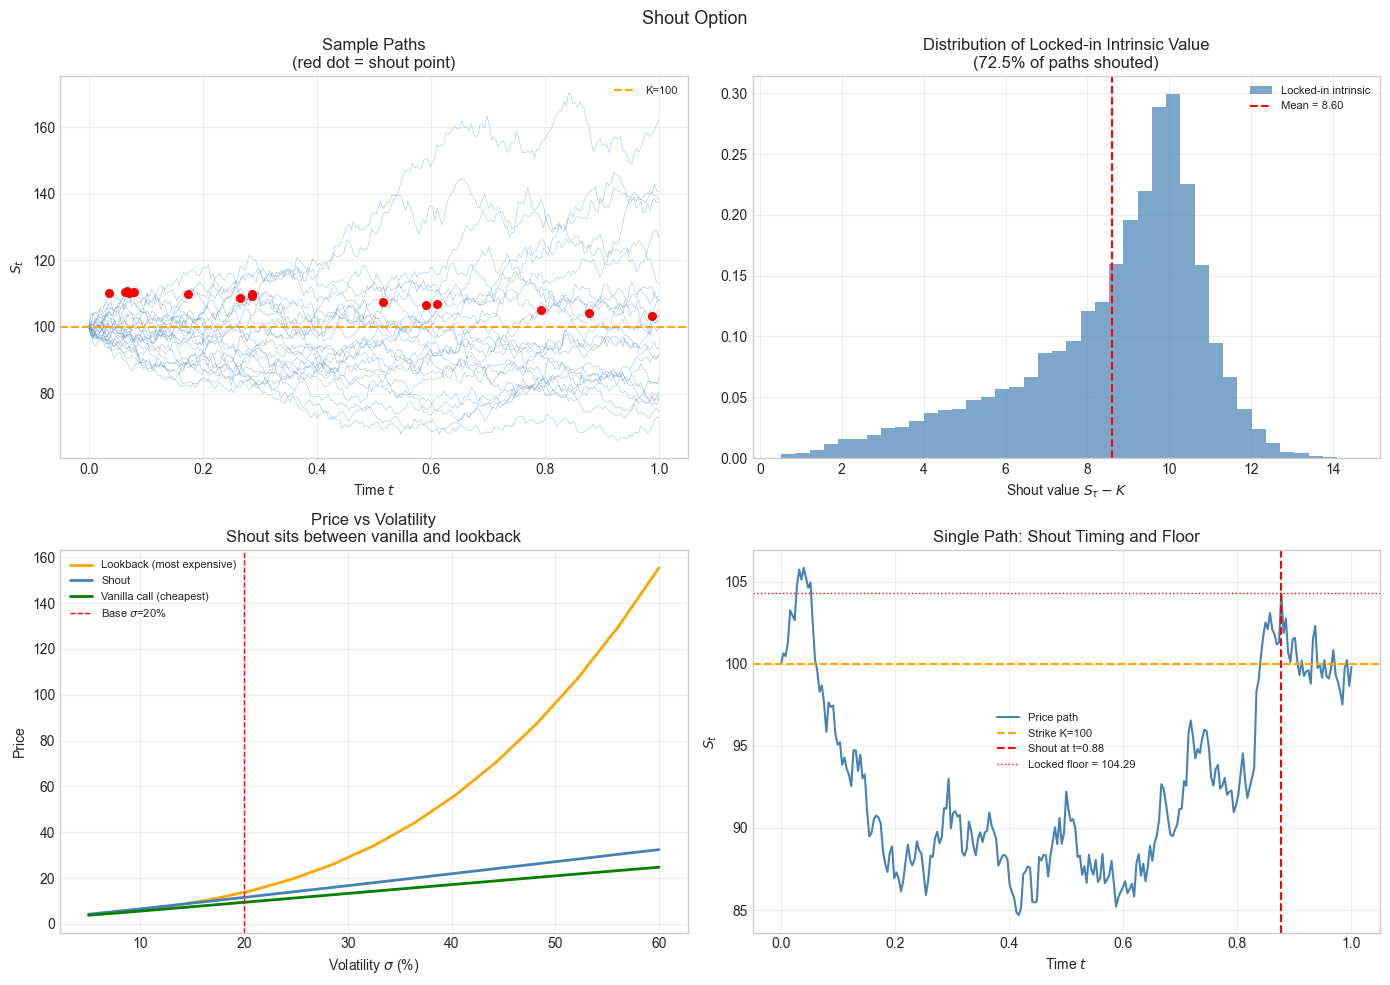

In [ ]:
# --- Shout Option ---

# def simulate_shout(S0, K, T, r, sigma, n_steps, N_paths, seed=42):
#     """
#     Monte Carlo for shout option using optimal shout strategy.
#     Holder shouts when BSM ATM call value = current intrinsic value.
#     Payoff = max(S_T - K, S_tau - K, 0)
#     """
#     np.random.seed(seed)
#     dt         = T / n_steps
#     paths      = np.zeros((N_paths, n_steps + 1))
#     paths[:,0] = S0

#     Z = np.random.standard_normal((N_paths, n_steps))
#     for t in range(1, n_steps + 1):
#         paths[:,t] = paths[:,t-1] * np.exp(
#             (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:,t-1]
#         )

#     shout_values = np.zeros(N_paths)
#     shouted      = np.zeros(N_paths, dtype=bool)

#     for t in range(1, n_steps):
#         time_remaining = T - t*dt
#         S_t            = paths[:,t]
#         intrinsic      = np.maximum(S_t - K, 0)

#         # ATM forward starting call value at current spot
#         atm_call = np.array([
#             bsm_price(s, s, time_remaining, r, sigma, 'call') 
#             for s in S_t
#         ])

#         # shout if intrinsic >= ATM call and not yet shouted
#         should_shout = (~shouted) & (intrinsic >= atm_call) & (intrinsic > 0)
#         shout_values[should_shout] = intrinsic[should_shout]
#         shouted[should_shout]      = True

#     # terminal payoff
#     S_T    = paths[:,-1]
#     payoff = np.maximum(S_T - K, np.maximum(shout_values, 0))
#     price  = np.exp(-r*T) * payoff.mean()
#     se     = np.exp(-r*T) * payoff.std() / np.sqrt(N_paths)
#     return price, se, paths, shout_values, shouted

def simulate_shout(S0, K, T, r, sigma, n_steps, N_paths, seed=42):
    np.random.seed(seed)
    dt         = T / n_steps
    paths      = np.zeros((N_paths, n_steps + 1))
    paths[:,0] = S0

    Z = np.random.standard_normal((N_paths, n_steps))
    for t in range(1, n_steps + 1):
        paths[:,t] = paths[:,t-1] * np.exp(
            (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:,t-1]
        )

    shout_values = np.zeros(N_paths)
    shouted      = np.zeros(N_paths, dtype=bool)

    for t in range(1, n_steps):
        time_remaining = T - t*dt
        S_t       = paths[:,t]
        intrinsic = np.maximum(S_t - K, 0)

        # vectorized BSM ATM call: S=K=S_t so ln(S/K)=0
        d1       = (r + 0.5*sigma**2) * time_remaining / (sigma*np.sqrt(time_remaining))
        d2       = d1 - sigma*np.sqrt(time_remaining)
        atm_call = S_t * norm.cdf(d1) - S_t * np.exp(-r*time_remaining) * norm.cdf(d2)

        should_shout = (~shouted) & (intrinsic >= atm_call) & (intrinsic > 0)
        shout_values[should_shout] = intrinsic[should_shout]
        shouted[should_shout]      = True

    S_T    = paths[:,-1]
    payoff = np.maximum(S_T - K, np.maximum(shout_values, 0))
    price  = np.exp(-r*T) * payoff.mean()
    se     = np.exp(-r*T) * payoff.std() / np.sqrt(N_paths)
    return price, se, paths, shout_values, shouted

# Parameters
n_steps = 252
N_paths = 20000

price_shout, se_shout, paths, shout_vals, shouted = simulate_shout(
    S0, K, T, r, sigma, n_steps, N_paths)
vanilla  = bsm_price(S0, K, T, r, sigma, 'call')
lookback = lookback_float_call_exact(S0, T, r, sigma)

print(f'Vanilla call   : {vanilla:.4f}')
print(f'Shout option   : {price_shout:.4f} +/- {se_shout:.4f}')
print(f'Lookback call  : {lookback:.4f}')
print(f'% paths shouted: {shouted.mean()*100:.1f}%')
print(f'Mean shout value (when shouted): {shout_vals[shouted].mean():.4f}')

# Sensitivity to sigma
vols        = np.linspace(0.05, 0.60, 15)
prices_shout_vol   = [simulate_shout(S0, K, T, r, s, n_steps, N_paths)[0] 
                      for s in vols]
prices_vanilla_vol = [bsm_price(S0, K, T, r, s, 'call') for s in vols]
prices_lookback_vol = [lookback_float_call_exact(S0, T, r, s) for s in vols]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Shout Option', fontsize=13)

# Panel 1: sample paths with shout points marked
n_show  = 15
t_grid  = np.linspace(0, T, n_steps + 1)
shouted_shown = 0
for i in range(N_paths):
    if shouted_shown >= n_show:
        break
    axes[0,0].plot(t_grid, paths[i], color='steelblue', lw=0.5, alpha=0.4)
    if shouted[i]:
        # find shout day
        shout_day = next(
            (t for t in range(1, n_steps) 
             if np.maximum(paths[i,t]-K, 0) >= 
             bsm_price(paths[i,t], paths[i,t], T-t/n_steps*T, r, sigma, 'call')
             and paths[i,t] > K), None
        )
        if shout_day:
            axes[0,0].scatter(t_grid[shout_day], paths[i,shout_day],
                              color='red', s=30, zorder=5)
        shouted_shown += 1

axes[0,0].axhline(K, color='orange', lw=1.5, ls='--', label=f'K={K}')
axes[0,0].set_title('Sample Paths\n(red dot = shout point)')
axes[0,0].set_xlabel('Time $t$')
axes[0,0].set_ylabel('$S_t$')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# Panel 2: distribution of shout values
axes[0,1].hist(shout_vals[shouted], bins=40, color='steelblue',
               alpha=0.7, density=True, label='Locked-in intrinsic')
axes[0,1].axvline(shout_vals[shouted].mean(), color='red', lw=1.5, ls='--',
                   label=f'Mean = {shout_vals[shouted].mean():.2f}')
axes[0,1].set_title(f'Distribution of Locked-in Intrinsic Value\n({shouted.mean()*100:.1f}% of paths shouted)')
axes[0,1].set_xlabel('Shout value $S_\\tau - K$')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# Panel 3: price comparison across volatilities
axes[1,0].plot(np.array(vols)*100, np.array(prices_lookback_vol),
               color='orange',    lw=2, label='Lookback (most expensive)')
axes[1,0].plot(np.array(vols)*100, np.array(prices_shout_vol),
               color='steelblue', lw=2, label='Shout')
axes[1,0].plot(np.array(vols)*100, np.array(prices_vanilla_vol),
               color='green',     lw=2, label='Vanilla call (cheapest)')
axes[1,0].axvline(sigma*100, color='red', lw=1, ls='--',
                   label=f'Base $\\sigma$={sigma*100:.0f}%')
axes[1,0].set_title('Price vs Volatility\nShout sits between vanilla and lookback')
axes[1,0].set_xlabel('Volatility $\\sigma$ (%)')
axes[1,0].set_ylabel('Price')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

# Panel 4: payoff decomposition for a single path
path_idx = next(i for i in range(N_paths) if shouted[i])
axes[1,1].plot(t_grid, paths[path_idx], color='steelblue', lw=1.5,
               label='Price path')
axes[1,1].axhline(K,   color='orange', lw=1.5, ls='--', label=f'Strike K={K}')
shout_day = next(
    (t for t in range(1, n_steps)
     if np.maximum(paths[path_idx,t]-K, 0) >=
     bsm_price(paths[path_idx,t], paths[path_idx,t],
               T-t/n_steps*T, r, sigma, 'call')
     and paths[path_idx,t] > K), None
)
if shout_day:
    axes[1,1].axvline(t_grid[shout_day], color='red', lw=1.5, ls='--',
                       label=f'Shout at t={t_grid[shout_day]:.2f}')
    axes[1,1].axhline(paths[path_idx, shout_day], color='red', lw=1,
                       ls=':', label=f'Locked floor = {paths[path_idx,shout_day]:.2f}')
axes[1,1].set_title('Single Path: Shout Timing and Floor')
axes[1,1].set_xlabel('Time $t$')
axes[1,1].set_ylabel('$S_t$')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Rainbow Options

Rainbow is the general family name for multi-asset options whose payoff depends 
on the relative performance of multiple underlyings. Best-of and worst-of are 
the most common members of that family.

<small> 

| Product | Payoff |
|---|---|
| Best-of call | $\max\left(\max(S_1, \ldots, S_n) - K,\ 0\right)$ |
| Worst-of call | $\max\left(\min(S_1, \ldots, S_n) - K,\ 0\right)$ |
| Best-of asset-or-nothing | $\max(S_1, \ldots, S_n)$ at maturity, no strike |
| Worst-of asset-or-nothing | $\min(S_1, \ldots, S_n)$ at maturity, no strike |
| Outperformance option | $\max(S_1 - S_2,\ 0)$ |
| Spread option | $\max\left((S_1 - S_2) - K,\ 0\right)$ |

</small> 

The dominant risk factor across all rainbow options is **correlation** $\rho$, 
more so than individual volatility. Lower correlation means the underlyings 
are more likely to diverge:

- **best-of** becomes more expensive: higher chance one asset performs very well
- **worst-of** becomes cheaper: higher chance one asset performs very badly

Spread options are particularly common in **energy markets**: for example the 
crack spread $(\text{oil} - \text{gasoline})$ or the spark spread 
$(\text{gas} - \text{electricity})$, where the payoff depends on the difference 
between two correlated commodity prices.

## 15. Best-of and Worst-of Options

Best-of and worst-of options are the most common members of the rainbow 
family. The payoff depends on the **best or worst performing asset** among 
$n$ underlyings $S^{(1)}, \ldots, S^{(n)}$. The key pricing parameter is 
**correlation** $\rho$ between the underlyings, more so than individual 
volatility.

#### Best-of Call

Pays the call on the **best performing** asset at maturity:

$$\text{Payoff} = \max\left(\max_{i=1,\ldots,n} S^{(i)}_T - K,\ 0\right)$$

#### Worst-of Call

Pays the call on the **worst performing** asset at maturity:

$$\text{Payoff} = \max\left(\min_{i=1,\ldots,n} S^{(i)}_T - K,\ 0\right)$$

#### Worst-of Put

Pays the put on the **worst performing** asset at maturity:

$$\text{Payoff} = \max\left(K - \min_{i=1,\ldots,n} S^{(i)}_T,\ 0\right)$$

#### Effect of correlation

<small> 

| | Best-of Call | Worst-of Call | Worst-of Put |
|---|---|---|---|
| $\rho \to 1$ | Converges to vanilla call | Converges to vanilla call | Converges to vanilla put |
| $\rho \to -1$ | Most expensive | Cheapest | Most expensive |
| $\rho \to 0$ | Expensive | Cheap | Expensive |

</small> 

Lower correlation means the assets are more likely to **diverge**:
- **best-of** becomes more expensive: higher chance one asset rallies strongly
- **worst-of** becomes cheaper: higher chance one asset performs very badly

#### Closed-form for $n=2$ (Stulz 1982)

For two assets $S^{(1)}, S^{(2)}$ with correlation $\rho$, the 
**worst-of call** price is:

$$C_{\text{WO}} = C_1 + C_2 - C_{\text{best-of}}$$

where $C_1, C_2$ are vanilla BSM calls on each asset and:

$$C_{\text{best-of}} = S^{(1)}_0 \mathcal{N}_2(d_1^{(1)}, -e_1; -\rho_1) + 
S^{(2)}_0 \mathcal{N}_2(d_1^{(2)}, -e_2; -\rho_2) - 
Ke^{-rT}\mathcal{N}_2(d_2^{(1)}, d_2^{(2)}; \rho)$$

where $\mathcal{N}_2(\cdot, \cdot; \rho)$ is the bivariate normal CDF and:

$$d_1^{(i)} = \frac{\ln(S^{(i)}_0/K) + (r + \frac{\sigma_i^2}{2})T}{\sigma_i\sqrt{T}}, 
\quad d_2^{(i)} = d_1^{(i)} - \sigma_i\sqrt{T}$$

$$e_1 = \frac{\ln(S^{(1)}_0/S^{(2)}_0) + \frac{1}{2}(\sigma_1^2 - \sigma_2^2)T}{\sigma\sqrt{T}}, 
\quad \sigma = \sqrt{\sigma_1^2 + \sigma_2^2 - 2\rho\sigma_1\sigma_2}$$

**Finance application**: worst-of options are embedded in **autocallable 
structured notes** and **dual currency deposits**. The investor sells 
correlation risk to the issuer in exchange for a higher coupon or capital 
protection. Best-of options are used in **multi-asset participation notes** 
where the investor wants exposure to the strongest performing asset.

**Note.** The best-of and worst-of calls reduce to the **asset-or-nothing** 
case when $K = 0$: with no strike to deduct, the payoff is simply the full 
value of the best or worst performing asset at maturity:

$$K = 0 \implies \text{Best-of call} = \max_{i=1,\ldots,n} S^{(i)}_T, 
\qquad \text{Worst-of call} = \min_{i=1,\ldots,n} S^{(i)}_T$$

rho=+0.9  ->  Worst-of Put price: 9.6201
rho=+0.5  ->  Worst-of Put price: 12.5315
rho=+0.1  ->  Worst-of Put price: 14.7792
rho=-0.2  ->  Worst-of Put price: 16.2906

Single-asset Put (sigma=20%): 6.4580
Worst-of put is cheaper because of additional uncertainty about which asset performs worst.
Done.


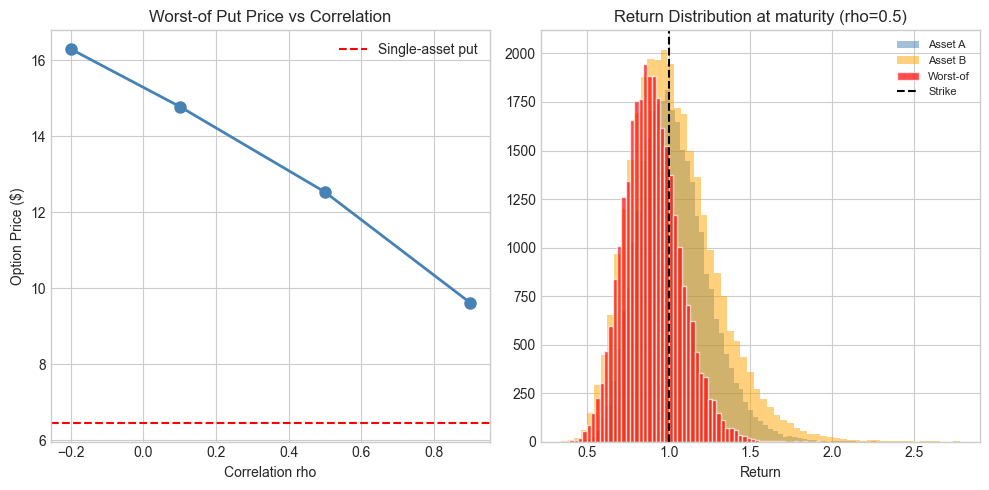

In [ ]:
# --- Worst-Of Option: Correlated GBM Monte Carlo ---

def simulate_correlated_gbm(S0_vec, r, sigma_vec, rho_matrix, T, n_steps, n_paths):
    n_assets = len(S0_vec)
    L        = np.linalg.cholesky(rho_matrix)
    dt       = T / n_steps

    # drift and diffusion as vectors across assets
    drift = (r - 0.5 * sigma_vec**2) * dt                 # shape (n_assets,)
    diff_scale = sigma_vec * np.sqrt(dt)                  # shape (n_assets,)

    paths        = np.zeros((n_paths, n_steps + 1, n_assets))
    paths[:, 0, :] = S0_vec

    for t in range(1, n_steps + 1):
        Z      = np.random.standard_normal((n_paths, n_assets))
        Z_corr = Z @ L.T                                  # shape (n_paths, n_assets)
        
        # broadcast across all paths and assets
        paths[:, t, :] = paths[:, t-1, :] * np.exp(drift + diff_scale * Z_corr)
    return paths

# Three assets: stock A, B, C
S0_vec    = np.array([100.0, 100.0, 100.0])
sigma_vec = np.array([0.20, 0.25, 0.18])
K_pct     = 1.0   # strike = initial level (ATM)
n_steps_wo = 52   # weekly steps
N_wo       = 30000

# Price worst-of put under different correlation regimes
rho_values = [0.9, 0.5, 0.1, -0.2]
prices = []

for rho in rho_values:
    rho_mat = np.array([[1.0,  rho,  rho],
                        [rho,  1.0,  rho],
                        [rho,  rho,  1.0]])
    paths_wo = simulate_correlated_gbm(S0_vec, r, sigma_vec, rho_mat, T, n_steps_wo, N_wo)
    S_T_all  = paths_wo[:, -1, :]            # final prices, shape (N, 3)
    returns  = S_T_all / S0_vec              # normalised returns
    worst    = returns.min(axis=1)           # worst performer each path
    payoff   = np.maximum(K_pct - worst, 0)
    price    = np.exp(-r * T) * np.mean(payoff) * S0_vec[0]  # in $ terms
    prices.append(price)
    print(f'rho={rho:+.1f}  ->  Worst-of Put price: {price:.4f}')

# Baseline: single-asset put for comparison
single_put = bsm_price(S0, K, T, r, sigma_vec[0], 'put')
print(f'\nSingle-asset Put (sigma=20%): {single_put:.4f}')
print('Worst-of put is cheaper because of additional uncertainty about which asset performs worst.')

# Correlation impact chart
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].plot(rho_values, prices, 'o-', color='steelblue', lw=2, markersize=8)
axes[0].axhline(single_put, color='red', lw=1.5, linestyle='--', label='Single-asset put')
axes[0].set_title('Worst-of Put Price vs Correlation')
axes[0].set_xlabel('Correlation rho'); axes[0].set_ylabel('Option Price ($)')
axes[0].legend()

# Distribution of worst performer at rho=0.5
rho_mat_mid = np.array([[1., .5, .5],[.5, 1., .5],[.5, .5, 1.]])
paths_mid   = simulate_correlated_gbm(S0_vec, r, sigma_vec, rho_mat_mid, T, n_steps_wo, N_wo)
returns_mid = paths_mid[:, -1, :] / S0_vec
worst_mid   = returns_mid.min(axis=1)

axes[1].hist(returns_mid[:, 0], bins=60, alpha=0.5, label='Asset A', color='steelblue')
axes[1].hist(returns_mid[:, 1], bins=60, alpha=0.5, label='Asset B', color='orange')
axes[1].hist(worst_mid,         bins=60, alpha=0.7, label='Worst-of', color='red', edgecolor='white')
axes[1].axvline(1.0, color='black', lw=1.5, linestyle='--', label='Strike')
axes[1].set_title('Return Distribution at maturity (rho=0.5)')
axes[1].set_xlabel('Return'); axes[1].legend(fontsize=8)
plt.tight_layout(); 
print('Done.')

## 16. Spread and Outperformance Options

A spread option pays the difference between two asset prices minus a strike 
$K$ if positive. It is driven by the **relative performance** of two assets 
rather than their absolute levels.

$$\text{Payoff} = \max\left(S^{(1)}_T - S^{(2)}_T - K,\ 0\right)$$

#### Special case: Outperformance Option ($K=0$)

When $K=0$ the spread option reduces to the **outperformance option**, paying 
the full outperformance of asset 1 over asset 2:

$$\text{Payoff} = \max\left(S^{(1)}_T - S^{(2)}_T,\ 0\right)$$

The holder profits if and only if asset 1 finishes above asset 2, regardless 
of the absolute level of either.

#### Closed-form: Margrabe Formula (1978)

For the outperformance option ($K=0$) there is an exact closed form:

$$V = S^{(1)}_0 \mathcal{N}(d_1) - S^{(2)}_0 \mathcal{N}(d_2)$$

where:

$$d_1 = \frac{\ln(S^{(1)}_0/S^{(2)}_0) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}, 
\qquad d_2 = d_1 - \sigma\sqrt{T}$$

$$\sigma = \sqrt{\sigma_1^2 + \sigma_2^2 - 2\rho\sigma_1\sigma_2}$$

This is the **volatility of the spread** $S^{(1)} - S^{(2)}$, which decreases 
with correlation $\rho$. When $\rho \to 1$ the assets move together and the 
spread has low volatility, making the outperformance option cheap. When 
$\rho \to -1$ the spread is very volatile and the option is expensive.

For $K > 0$ there is no exact closed form. The standard approximation is the 
**Kirk approximation**:

$$V_{\text{Kirk}} \approx C_{\text{BSM}}\left(S^{(1)}_0,\ S^{(2)}_0 + Ke^{-rT},\ 
T,\ 0,\ \sigma_{\text{Kirk}}\right)$$

$$\sigma_{\text{Kirk}} = \sqrt{\sigma_1^2 - 2\rho\sigma_1\sigma_2 
\frac{S^{(2)}_0}{S^{(2)}_0 + Ke^{-rT}} + \sigma_2^2 
\left(\frac{S^{(2)}_0}{S^{(2)}_0 + Ke^{-rT}}\right)^2}$$

#### Effect of correlation

$$\frac{\partial V}{\partial \rho} < 0$$

Higher correlation makes both assets move together, reducing spread volatility 
$\sigma$ and making the option cheaper. This is the opposite of most multi-asset 
options: the spread option is **long correlation risk in reverse**, it benefits 
from low or negative correlation.

#### Finance applications

- **Energy markets**: crack spread (crude oil vs refined products), spark spread 
  (natural gas vs electricity), dark spread (coal vs electricity)
- **Fixed income**: yield curve spread options, swap spread options
- **Equity**: sector rotation trades, pairs trading with optionality
- **M&A arbitrage**: outperformance of target vs acquirer stock

Outperformance (Margrabe exact): 9.1210
Outperformance (MC)            : 9.0946 +/- 0.0579
Spread K=5.0 (Kirk approx)     : 6.8204
Spread K=5.0 (MC)              : 6.7882 +/- 0.0505


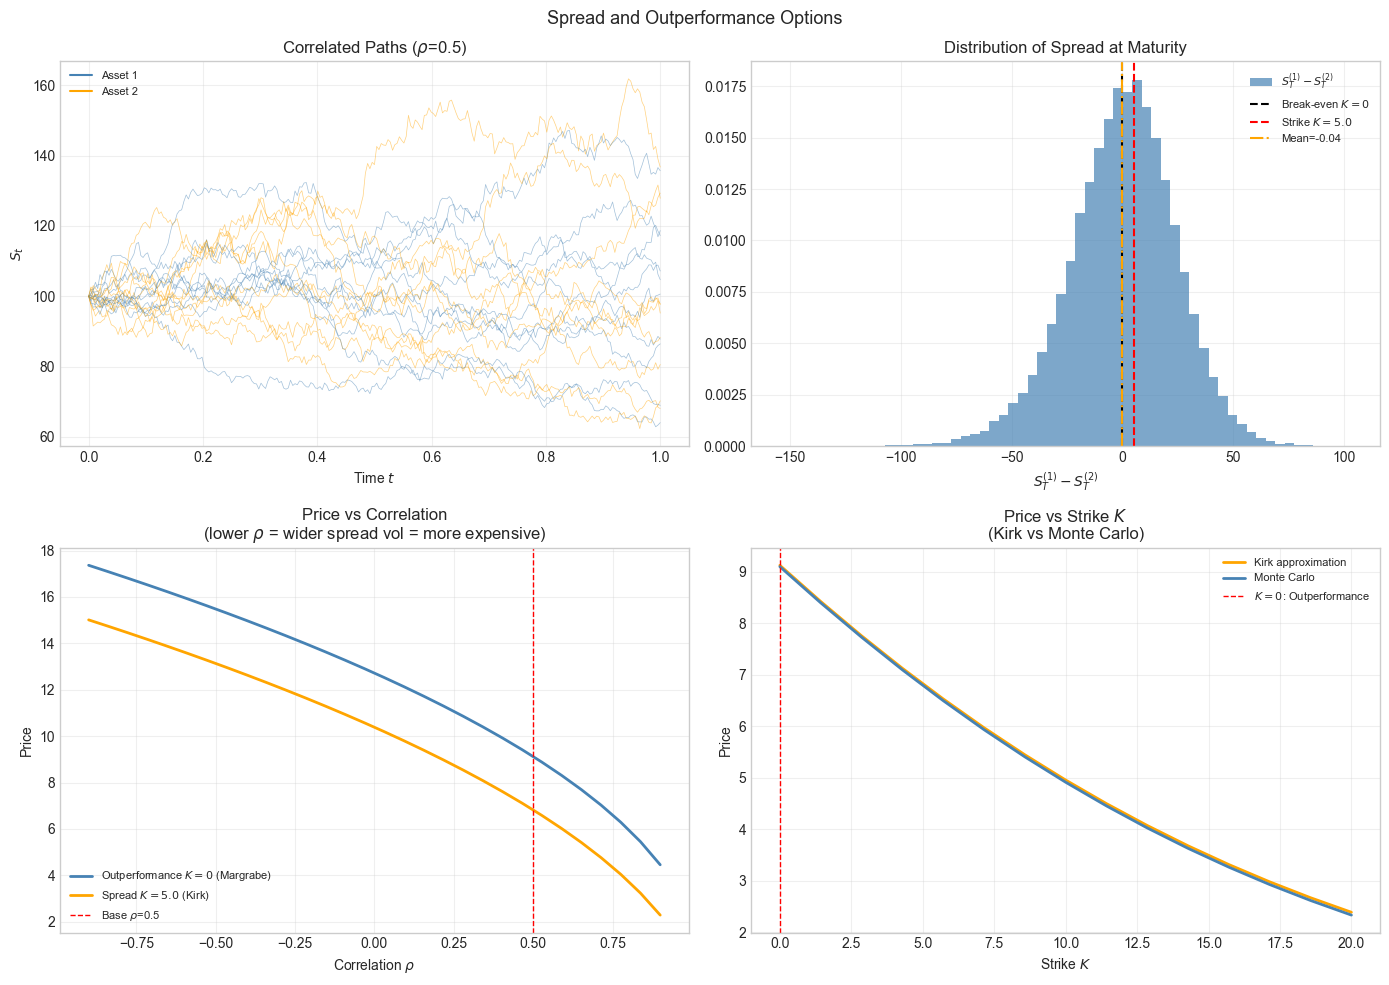

In [ ]:
# --- Spread and Outperformance Options ---

def margrabe_price(S1, S2, T, r, sigma1, sigma2, rho):
    """Exact Margrabe formula for outperformance option (K=0)."""
    sigma = np.sqrt(sigma1**2 + sigma2**2 - 2*rho*sigma1*sigma2)
    if sigma <= 0:
        return max(S1 - S2, 0)
    d1 = (np.log(S1/S2) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S1*norm.cdf(d1) - S2*norm.cdf(d2)

def kirk_price(S1, S2, K, T, r, sigma1, sigma2, rho):
    """Kirk approximation for spread option with K > 0."""
    F2       = S2 + K*np.exp(-r*T)
    sigma_k  = np.sqrt(sigma1**2 - 2*rho*sigma1*sigma2*(S2/F2) + 
                       sigma2**2*(S2/F2)**2)
    return bsm_price(S1, F2, T, 0, sigma_k, 'call')

# def simulate_spread(S0_1, S0_2, K, T, r, sigma1, sigma2, rho,
#                     n_steps, N_paths, seed=42):
#     """Monte Carlo for spread option."""
#     np.random.seed(seed)
#     dt       = T / n_steps
#     rho_mat  = np.array([[1.0, rho], [rho, 1.0]])
#     L        = np.linalg.cholesky(rho_mat)
#     paths    = np.zeros((N_paths, 2, n_steps+1))
#     paths[:,0,0] = S0_1
#     paths[:,1,0] = S0_2

#     for t in range(1, n_steps+1):
#         Z     = np.random.standard_normal((N_paths, 2))
#         Z_cor = Z @ L.T
#         paths[:,0,t] = paths[:,0,t-1] * np.exp(
#             (r - 0.5*sigma1**2)*dt + sigma1*np.sqrt(dt)*Z_cor[:,0])
#         paths[:,1,t] = paths[:,1,t-1] * np.exp(
#             (r - 0.5*sigma2**2)*dt + sigma2*np.sqrt(dt)*Z_cor[:,1])

#     S1_T   = paths[:,0,-1]
#     S2_T   = paths[:,1,-1]
#     payoff = np.maximum(S1_T - S2_T - K, 0)
#     price  = np.exp(-r*T) * payoff.mean()
#     se     = np.exp(-r*T) * payoff.std() / np.sqrt(N_paths)
#     return price, se, paths, S1_T, S2_T

def simulate_spread(S0_1, S0_2, K, T, r, sigma1, sigma2, rho,
                    n_steps, N_paths, seed=42):
    np.random.seed(seed)
    dt      = T / n_steps
    L       = np.linalg.cholesky(np.array([[1.0, rho], [rho, 1.0]]))
    drift   = np.array([(r - 0.5*sigma1**2)*dt, (r - 0.5*sigma2**2)*dt])
    diffuse = np.array([sigma1*np.sqrt(dt),      sigma2*np.sqrt(dt)])

    paths      = np.zeros((N_paths, 2, n_steps+1))
    paths[:,0,0] = S0_1
    paths[:,1,0] = S0_2

    for t in range(1, n_steps+1):
        Z_cor          = np.random.standard_normal((N_paths, 2)) @ L.T
        paths[:,:,t]   = paths[:,:,t-1] * np.exp(drift + diffuse * Z_cor)

    S1_T   = paths[:,0,-1]
    S2_T   = paths[:,1,-1]
    payoff = np.maximum(S1_T - S2_T - K, 0)
    price  = np.exp(-r*T) * payoff.mean()
    se     = np.exp(-r*T) * payoff.std() / np.sqrt(N_paths)
    return price, se, paths, S1_T, S2_T

# Parameters
S0_1   = S0
S0_2   = S0
sigma1 = 0.20
sigma2 = 0.25
rho_base = 0.5
K_spread = 5.0
N_paths  = 50000
n_steps  = 252

# Prices
margrabe   = margrabe_price(S0_1, S0_2, T, r, sigma1, sigma2, rho_base)
kirk       = kirk_price(S0_1, S0_2, K_spread, T, r, sigma1, sigma2, rho_base)
mc_out, se_out, paths, S1_T, S2_T = simulate_spread(
    S0_1, S0_2, 0, T, r, sigma1, sigma2, rho_base, n_steps, N_paths)
mc_spread, se_sp, _, _, _ = simulate_spread(
    S0_1, S0_2, K_spread, T, r, sigma1, sigma2, rho_base, n_steps, N_paths)

print(f'Outperformance (Margrabe exact): {margrabe:.4f}')
print(f'Outperformance (MC)            : {mc_out:.4f} +/- {se_out:.4f}')
print(f'Spread K={K_spread} (Kirk approx)     : {kirk:.4f}')
print(f'Spread K={K_spread} (MC)              : {mc_spread:.4f} +/- {se_sp:.4f}')

# Sensitivity to correlation
rhos          = np.linspace(-0.9, 0.9, 30)
margrabe_rhos = [margrabe_price(S0_1, S0_2, T, r, sigma1, sigma2, rho) 
                 for rho in rhos]
kirk_rhos     = [kirk_price(S0_1, S0_2, K_spread, T, r, sigma1, sigma2, rho) 
                 for rho in rhos]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Spread and Outperformance Options', fontsize=13)

# Panel 1: simulated paths of both assets and spread
t_grid = np.linspace(0, T, n_steps+1)
n_show = 10
for i in range(n_show):
    axes[0,0].plot(t_grid, paths[i,0,:], color='steelblue', lw=0.5, alpha=0.5)
    axes[0,0].plot(t_grid, paths[i,1,:], color='orange',    lw=0.5, alpha=0.5)
axes[0,0].plot([], [], color='steelblue', label='Asset 1')
axes[0,0].plot([], [], color='orange',    label='Asset 2')
axes[0,0].set_title(f'Correlated Paths ($\\rho$={rho_base})')
axes[0,0].set_xlabel('Time $t$')
axes[0,0].set_ylabel('$S_t$')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# Panel 2: distribution of spread at maturity
spread_T = S1_T - S2_T
axes[0,1].hist(spread_T, bins=60, color='steelblue', alpha=0.7,
               density=True, label='$S^{(1)}_T - S^{(2)}_T$')
axes[0,1].axvline(0,        color='black', lw=1.5, ls='--', label='Break-even $K=0$')
axes[0,1].axvline(K_spread, color='red',   lw=1.5, ls='--', label=f'Strike $K={K_spread}$')
axes[0,1].axvline(spread_T.mean(), color='orange', lw=1.5, ls='-.',
                   label=f'Mean={spread_T.mean():.2f}')
axes[0,1].set_title('Distribution of Spread at Maturity')
axes[0,1].set_xlabel('$S^{(1)}_T - S^{(2)}_T$')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# Panel 3: price vs correlation
axes[1,0].plot(rhos, margrabe_rhos, color='steelblue', lw=2,
               label='Outperformance $K=0$ (Margrabe)')
axes[1,0].plot(rhos, kirk_rhos,     color='orange',    lw=2,
               label=f'Spread $K={K_spread}$ (Kirk)')
axes[1,0].axvline(rho_base, color='red', lw=1, ls='--',
                   label=f'Base $\\rho$={rho_base}')
axes[1,0].set_title('Price vs Correlation\n(lower $\\rho$ = wider spread vol = more expensive)')
axes[1,0].set_xlabel('Correlation $\\rho$')
axes[1,0].set_ylabel('Price')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

# Panel 4: price vs strike K (Kirk vs MC)
K_range    = np.linspace(0, 20, 15)
kirk_k     = [kirk_price(S0_1, S0_2, k, T, r, sigma1, sigma2, rho_base) 
              for k in K_range]
mc_k       = [simulate_spread(S0_1, S0_2, k, T, r, sigma1, sigma2, 
                               rho_base, n_steps, N_paths)[0] for k in K_range]

axes[1,1].plot(K_range, kirk_k, color='orange',    lw=2, label='Kirk approximation')
axes[1,1].plot(K_range, mc_k,   color='steelblue', lw=2, label='Monte Carlo')
axes[1,1].axvline(0, color='red', lw=1, ls='--', label='$K=0$: Outperformance')
axes[1,1].set_title('Price vs Strike $K$\n(Kirk vs Monte Carlo)')
axes[1,1].set_xlabel('Strike $K$')
axes[1,1].set_ylabel('Price')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Summary: Product Comparison
<small> 

| Product | Direction | Path dependent | Leverage | Main use case |
|---------|-----------|---------------|----------|---------------|
| TRS | Long/Short | No | Yes | Leveraged equity exposure |
| Forward | Long/Short | No | Implicit | Price lock-in |
| Vanilla Call/Put | Long/Short | No | Yes | Directional bet, hedging |
| CFD | Long/Short | No | Yes | Short-term leveraged trading |
| Digital (Cash-or-Nothing) | Long/Short | No | Yes | Binary bet on level at expiry |
| Digital (Asset-or-Nothing) | Long/Short | No | Yes | Receive asset if ITM at expiry |
| Chooser | Long | No | Yes | Choose call or put at future date |
| Compound | Long | No | Yes | Option on an option, staged investment |
| Down-and-Out Call | Long | Yes | Yes | Cheaper directional bet |
| Down-and-In Call | Long | Yes | Yes | Bet on dip then recovery |
| Up-and-Out Call | Long | Yes | Yes | Capped rally bet, cheaper |
| Asian (Average Price) | Long/Short | Yes | Yes | Reduce spot manipulation risk, commodities |
| Asian (Average Strike) | Long/Short | Yes | Yes | FX hedging over a period |
| Lookback (Fixed Strike) | Long | Yes | Yes | Buy at realized minimum |
| Lookback (Floating Strike) | Long | Yes | Yes | Capture maximum realized return |
| Accumulator | Long (forced) | Yes | Yes | Buy shares at discount, high tail risk |
| Decumulator | Short (forced) | Yes | Yes | Sell shares at premium, misses rallies |
| Cliquet (Ratchet) | Long | Yes | Yes | Lock in periodic gains, structured notes |
| Napoleon | Long | Yes | Yes | Sum of worst monthly returns, yield enhancement |
| Shout | Long | Yes | Yes | Lock in intrinsic value once during life |
| Worst-of Put | Short correlation | No (European) | Yes | Structured product embedding, capital protection |
| Worst-of Call | Long | No | Yes | Cheap multi-asset upside, embedded in notes |
| Best-of Call | Long | No | Yes | Full upside on best performer |

</small> 



**Notes:**
- Asian options are the most common exotics in commodities and FX
- Cliquets and Napoleons are common in European retail structured products
- Digitals are building blocks for many structured payoffs and require careful handling near expiry due to their discontinuous payoff
- Rainbow and worst-of options are driven by **correlation** as much as volatility

---

# Key  Points

1. **Delta one products** have delta = 1, no optionality, move 1:1 with the underlying: TRS, forwards, CFDs.

2. **Barrier options** are always cheaper than their vanilla equivalent because the knock-out condition reduces the probability of payout and the knock-in condition requires an additional event to activate it.

3. **Knock-in + Knock-out = Vanilla** (parity relationship, always holds regardless of barrier level).

4. **Digitals**: discontinuous payoff at expiry makes delta and gamma explode near the strike close to maturity. In practice they are replicated with a tight call spread to avoid the discontinuity.

4. **Accumulators and decumulators**: the discount or premium on the forward price 
is not free. The client implicitly sells options to the issuer to fund it, and the 
knock-out barrier always protects the issuer, never the client.

    In the **accumulator** the client buys daily at $F(1-d)$. The knock-out terminates 
    the contract when stock rises above $H_{up}$, removing the benefit of continued cheap 
    buying precisely when the stock performs well. On the downside there is no exit: 
    the double-up forces the client to buy twice the daily quantity at above-market prices 
    into a falling market, with losses that are convex in the size of the drawdown. 
    The deeper the crash, the faster losses accelerate.

    In the **decumulator** the client sells daily at $F(1+p)$. The knock-out terminates 
    the contract when stock falls below $H_{down}$, removing the premium stream precisely 
    when the client needs it most. On the upside the double-down forces the client to sell 
    twice the daily quantity below market into a rising market, giving up twice the upside.

    Both structures only work in a narrow band around the forward price. In both tails 
    the client is either forced out of the contract or punished with a doubled obligation 
    at an unfavorable price. Both are short volatility positions: the discount or premium 
    is simply the compensation for selling this asymmetric risk to the issuer.

5. **Path dependent products**: barriers, accumulators, decumulators, asians, lookbacks, cliquets, napoleons and shouts all require the full path for pricing. 

6. **Multi-asset products**: rainbow, worst-of, best-of and compound options are driven by **correlation** as much as volatility. Lower correlation increases dispersion across underlyings, making worst-of cheaper and best-of more expensive. They are not path dependent.

7. **Cliquets and Napoleons**: the key risk is **forward volatility**, not spot volatility. The price depends on the implied volatility of future option resets, which is much harder to hedge than standard vega.



9. **Pricing methods**:
   - Closed-form BSM: vanilla calls and puts, digitals, single barrier options
   - Monte Carlo: path-dependent exotics (asian, lookback, cliquet, napoleon, accumulator), discrete barriers
   - PDE: continuous barrier options, American options
   - Cholesky decomposition: correlated multi-asset products (rainbow, worst-of, best-of)

10. **MiFID II**: all OTC structured products sold to retail or professional clients in the EU require a KID (Key Information Document), ex-ante cost disclosure, and product suitability assessment.